In [1]:
"""
File: convert_tng_to_spam.py
Author: Matthew Ogden
Email: ogdenm12@gmail.com
Github: mbogden
Created: 2024-Apr-11

Description: This script is designed to take IllustrisTNG subhalo data,
    and convert it into a format that can be used by the SPAM simulator. 

References: 
- Sections of this code were written with the assistance of ChatGPT made by OpenAI.
- TNG50 Simulation Data
    - Nelson, D. et al. (2015). The Illustris Simulation: Public Data Release. Astronomy and Computing, 13, 12–37. https://doi.org/10.1016/j.ascom.2015.09.003
    - Nelson, D. et al. (2019). First results from the TNG50 simulation: Galactic outflows driven by supernovae and black hole feedback. Monthly Notices of the Royal Astronomical Society, 490(3), 3234–3261. https://doi.org/10.1093/mnras/stz2306
    - Pillepich, A. et al. (2019). First results from the TNG50 simulation: The evolution of stellar and gaseous discs across cosmic time. Monthly Notices of the Royal Astronomical Society, 490(3), 3196–3233. https://doi.org/10.1093/mnras/stz2338

"""
# ================================ IMPORTS ================================ #
import os, sys, argparse, logging
import math, gzip
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpi4py import MPI
from scipy.interpolate import CubicSpline, CubicHermiteSpline, interp1d

# Add main project directory to import project modules
try:
    SCRIPT_DIRECTORY = os.path.dirname(os.path.realpath(__file__))
    PROJECT_DIRECTORY = os.path.dirname(SCRIPT_DIRECTORY)
    sys.path.append(PROJECT_DIRECTORY)

except:
    # Assume we are running from the script directory
    SCRIPT_DIRECTORY = os.getcwd()
    PROJECT_DIRECTORY = os.path.dirname(SCRIPT_DIRECTORY)
    
    # Also assume you might be in galStuff
    work_dir = os.getcwd()
    if 'galStuff' == work_dir.split('/')[-1]:
        PROJECT_DIRECTORY =  work_dir + '/galaxyJSPAM'
        sys.path.append(PROJECT_DIRECTORY)

# Import project modules
import IllustrisTNG.tng_functions as tf
import Optimization_Methods.optimization_manager as om
import Simulator.new_simulator as sim
import utilities.general_utility as gu

# ================================ GLOBALS ================================ #
# Global logger from main program
script_args, LOGGER = gu.initialize_environment()
logger = LOGGER # Because I hate typing all caps

buildEnv = True

# # If buildEnv is True, then we can assume we're in a jupyter notebook
if buildEnv:
    LOGGER.setLevel(logging.DEBUG)
    # Set NumPy print options to reduce the precision to 3 decimal places
    np.set_printoptions(precision=2)
    from importlib import reload

LOGGER.debug("Import Done")

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-h2y4a8qe because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Time:2025-01-30 11:17:39,009 - [1402862265.<module>] - DEBUG - Import Done


In [2]:
# ================================ INPUT ARGUMENTS ================================ #

# Define argument parser function 
def initParser():
    # Define
    parser = argparse.ArgumentParser()

    # Generic Arguments
    parser.add_argument('-i', '--input', type=str, help='Generic Input for misc functions')
    parser.add_argument('-o', '--output', type=str, help='Generic Output for misc functions')

    parser.add_argument('-i2', '--input_2', type=str, help='Generic Input for misc functions')
    parser.add_argument('-i3', '--input_3', type=str, help='Generic Input for misc functions')
    parser.add_argument('-i4', '--input_4', type=str, help='Generic Input for misc functions')

    # Specific Arguments
    parser.add_argument('-id', '--target_id', type=int, help='Target ID')
    parser.add_argument('-ow', '--overwrite', type=bool, default = False, help='Overwrite existing files')
    parser.add_argument('-f', '--function', type=str,  help='Function to run')

    return parser

# A temp parser to do internal development testing
PARSER = initParser()

# CORE FUNCTIONS
The following are the core functions needed to convert from TNG to SPAM.

In [3]:
# ================================ CONSTANTS ================================ #

# Constants from Java code
G_NEWTON = 6.67430e-11         # Gravitational constant in m^3 kg^-1 s^-2
KG_PER_SOLAR_MASS = 1.98892e30   # Solar mass in kg
METERS_PER_PC = 3.08567758128e16   # Meters per parsec
SECONDS_PER_YEAR = 3.15576e7    # Seconds per year

# THESE ARE PULLED FROM JAVA CODE of SPAM
# Derived units for calculations
MU_kg = 1.0e11 * KG_PER_SOLAR_MASS  # 1e11 solar masses in kg
DU_m = 15.0 * 1000 * METERS_PER_PC  # 15 kpc in meters
TU_s = math.sqrt(DU_m * DU_m * DU_m / (G_NEWTON * MU_kg))  # Time unit in seconds (Based on Kepler's third law...?)

# SPAM standard units
spam_units = {

    # Mass unit - ( 10^11 solar masses )
    "mass_unit_solar_masses": 1e11,  # Mass unit in solar masses
    "mass_unit_kg": 1e11 * KG_PER_SOLAR_MASS,  # Mass unit in kg

    # Distance unit - ( 15 kpc )
    "distance_unit_kpc": 15.0,  # Distance unit in kiloparsecs
    "distance_units_pc": 15.0 * 1000,  # Distance unit in parsecs
    "distance_unit_m": 15.0 * 1000 * METERS_PER_PC ,  # Distance unit in meters

    # Time unit - ( roughly 85 Myr )
    "time_unit_s": None,  # To be calculated below

    # Velocity unit - ( roughly 170 km/s )
    "velocity_unit_m_per_s": None,  # To be calculated below
    "velocity_unit_km_per_s": None,  # To be calculated below

    # Acceleration unit
    "acceleration_unit_m_per_s2": None,  # To be calculated below

}

# Calculate time unit using Kepler's third law
spam_units["time_unit_s"] = math.sqrt(
    spam_units["distance_unit_m"] ** 3 / (G_NEWTON * spam_units["mass_unit_kg"])
)

# Calculate velocity unit (distance unit per time unit)
spam_units["velocity_unit_m_per_s"] = spam_units["distance_unit_m"] / spam_units["time_unit_s"]
spam_units["velocity_unit_km_per_s"] = spam_units["velocity_unit_m_per_s"] / 1000 # 1000 meters per kilometer

# Calculate acceleration unit (velocity unit per time unit)
spam_units["acceleration_unit_m_per_s2"] = spam_units["velocity_unit_m_per_s"] / spam_units["time_unit_s"]

# Dictionary of units for specific fields in the IllustrisTNG data
tng_units = {
    # Mass unit: 1e10 solar masses in grams
    "mass_unit_solar_masses": 1e10,
    "mass_unit_kg": 1e10 * KG_PER_SOLAR_MASS,  # Convert kg to grams

    # Distance unit: 1 kpc in centimeters (comoving kiloparsecs per h)
    "distance_unit_kpc": 1.0,  # 1 kpc
    "distance_unit_pc" : 1e3, # 1 kpc in pc
    "distance_unit_m": 1e3 * METERS_PER_PC, # 1 kpc in meters

    # Velocity unit: 1 km/s in cm/s
    "velocity_unit_km_per_s": 1.0,

    # Time unit: 1 Gyr in seconds
    "time_unit_Gyr": 1.0,
    "time_unit_s": 1e9 * SECONDS_PER_YEAR,  # Convert Gyr to seconds
}

# Print comparing JAVA to Fortran units
if buildEnv:
    print("Mass Comparison: ")
    print("\t - Fortran (kg):", spam_units['mass_unit_kg'])
    print("\t - JAVA (kg):", MU_kg ) 

    print("Distance Comparison: ")
    print("\t - Fortran (m):", spam_units['distance_unit_m'])
    print("\t - JAVA (m):", DU_m )

    print("Time Comparison: ")
    print("\t - Fortran (s): %e" % spam_units['time_unit_s'])
    print("\t - JAVA (s): %e" % TU_s )

    print("\nValues are the same but in different units. \n")


#   Standardized parameter array for SPAM model:
'''
    [0]: X-coordinate of the secondary galaxy's position
    [1]: Y-coordinate of the secondary galaxy's position
    [2]: Z-coordinate of the secondary galaxy's position
    [3]: X-component of the secondary galaxy's velocity
    [4]: Y-component of the secondary galaxy's velocity
    [5]: Z-component of the secondary galaxy's velocity
    [6]: Mass of the primary galaxy
    [7]: Mass of the secondary galaxy
    [8]: Outer radius of the primary galaxy
    [9]: Outer radius of the secondary galaxy
    [10]: Azimuthal angle for the primary galaxy
    [11]: Azimuthal angle for the secondary galaxy
    [12]: Inclination angle for the primary galaxy
    [13]: Inclination angle for the secondary galaxy
    [14]: Softening length for the primary galaxy
    [15]: Softening length for the secondary galaxy
    [16-19]: Particle distribution of the primary galaxy. (Unused)
    [19-21]: Particle distribution of the secondary galaxy. (Unused)
'''

# Create diction naming the parameters
spam_param_name = {
    0: 'X-coordinate of the secondary galaxy\'s position',
    1: 'Y-coordinate of the secondary galaxy\'s position',
    2: 'Z-coordinate of the secondary galaxy\'s position',
    3: 'X-component of the secondary galaxy\'s velocity',
    4: 'Y-component of the secondary galaxy\'s velocity',
    5: 'Z-component of the secondary galaxy\'s velocity',
    6: 'Mass of the primary galaxy',
    7: 'Mass of the secondary galaxy',
    8: 'Outer radius of the primary galaxy',
    9: 'Outer radius of the secondary galaxy',
    10: 'Azimuthal angle for the primary galaxy',
    11: 'Azimuthal angle for the secondary galaxy',
    12: 'Inclination angle for the primary galaxy',
    13: 'Inclination angle for the secondary galaxy',
    14: 'Softening length for the primary galaxy',
    15: 'Softening length for the secondary galaxy',
    16: 'Particle distribution of the primary galaxy',
    17: 'Particle distribution of the primary galaxy',
    18: 'Particle distribution of the primary galaxy',
    19: 'Particle distribution of the primary galaxy',
    20: 'Particle distribution of the secondary galaxy',
    21: 'Particle distribution of the secondary galaxy',
    22: 'Particle distribution of the secondary galaxy',
    23: 'Particle distribution of the secondary galaxy',
}


Mass Comparison: 
	 - Fortran (kg): 1.98892e+41
	 - JAVA (kg): 1.98892e+41
Distance Comparison: 
	 - Fortran (m): 4.62851637192e+20
	 - JAVA (m): 4.62851637192e+20
Time Comparison: 
	 - Fortran (s): 2.733073e+15
	 - JAVA (s): 2.733073e+15

Values are the same but in different units. 



In [4]:
def convert_numpy_arrays( df ):
    """
    Convert strings of arrays into numpy arrays in a pandas DataFrame.
    """

    # Function to convert a string representation of a numpy array back to a numpy array
    def convert_to_numpy_array(array_str):
        # Remove the brackets and split the string by whitespace
        array_str = array_str.strip('[]')
        # Convert to a numpy array of integers (or float if needed)
        return np.array(array_str.split(), dtype=float)
    
    # Iterate over each column and convert strings to numpy arrays if necessary
    for column in df.columns:
        # Check if the column contains array-like strings
        if df[column].dtype == object and df[column].str.startswith('[').all():
            df[column] = df[column].apply(convert_to_numpy_array)

    return df

if buildEnv and True:
    
    # Specify the file path to illustrisTNG Target info
    file_path = '/home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/tng-targets/moi-4-targets.pkl'

    # Read the CSV file into a Pandas DataFrame
    tng_targets = pd.read_pickle(file_path, )
    print(f"All Targets: {len(tng_targets)}")

    # write note in a single string
    note = """
    #####   Special note of pre-fixes in file   #####
    1st character 'p' vs 's' indicates 'primary' vs 'secondary' galaxy.
    If 2nd character is absent, data is from illustrisTNG Subhalo Catalog Data.
    If 2nd character is present, data is dynamically calculated after doing historical particle re-attribution.
    2nd characters 'a' and 's' stand for 'all particles' and 'star particles' respectively.
    """
    print(note)
    
    print( tng_targets.columns )
    # for i, k in enumerate(tng_targets.columns):
    #     print(i, k)


All Targets: 1268

    #####   Special note of pre-fixes in file   #####
    1st character 'p' vs 's' indicates 'primary' vs 'secondary' galaxy.
    If 2nd character is absent, data is from illustrisTNG Subhalo Catalog Data.
    If 2nd character is present, data is dynamically calculated after doing historical particle re-attribution.
    2nd characters 'a' and 's' stand for 'all particles' and 'star particles' respectively.
    
Index(['moi_2', 'snap', 'merger_snap', 'p_moi_1', 's_moi_1', 'xy_projection',
       'p_face_projection', 's_face_projection', 'p_SubhaloID', 's_SubhaloID',
       ...
       'sa_SubhaloPos_orbital_frame', 'sa_SubhaloCM_orbital_frame',
       'sa_SubhaloVel_orbital_frame', 'sa_SubhaloSpin_orbital_frame',
       'ss_SubhaloPos_orbital_frame', 'ss_SubhaloCM_orbital_frame',
       'ss_SubhaloVel_orbital_frame', 'ss_SubhaloSpin_orbital_frame',
       'img_name_1', 'moi_4_rating'],
      dtype='object', length=111)


In [5]:
# Let's focus on a single target for development purposes
if buildEnv:

    # Convert entire column of moi_1, moi_2, p_SubhaloIDRaw, s_SubhaloIDRaw to int64
    # tng_targets['moi_1'] = tng_targets['moi_1'].astype('int64')
    tng_targets['moi_2'] = tng_targets['moi_2'].astype('int64')
    tng_targets['p_SubhaloIDRaw'] = tng_targets['p_SubhaloIDRaw'].astype('int64')
    tng_targets['s_SubhaloIDRaw'] = tng_targets['s_SubhaloIDRaw'].astype('int64')

    # Unique ID for primary galaxy
    pid = 62000000190717

    # Get row with this p_SubhaloIDRaw
    t_row = tng_targets.loc[ tng_targets['p_SubhaloIDRaw'] == pid ].iloc[0]

    # Get moi_2 id and grab all rows with this value
    m2_id = t_row['moi_2']
    print( f'MOI_2: {m2_id}' )
    t_df = tng_targets.loc[ tng_targets['moi_2'] == m2_id ]
    print(f'Target DF: {len(t_df)}\n')

    print(f'Target Row:\n{t_row}')

MOI_2: 67000000184181
Target DF: 26

Target Row:
moi_2                                                              67000000184181
snap                                                                           62
merger_snap                                                                  65.0
p_moi_1                                                          50000000220008.0
s_moi_1                                                          50000000220010.0
                                                      ...                        
ss_SubhaloCM_orbital_frame      [16.59689896769487, 0.6179258303454844, 0.0204...
ss_SubhaloVel_orbital_frame     [8.724396910270222, -58.22408825900726, -12.10...
ss_SubhaloSpin_orbital_frame    [-703.8460704236377, 612.369167093556, -5810.4...
img_name_1                                              Target_62000000190717.png
moi_4_rating                                                                    5
Name: 1010, Length: 111, dtype: object


In [6]:
# ================================ FUNCTIONS ================================ #
def calculate_orientation_angles( spin ):
    """
    Calculate the azimuthal and inclination angles from the spin components.

    Parameters:
    spin (float array): [ x, y, z ] components of the spin.

    Returns:
    tuple: (phi, theta) where phi is the azimuthal angle and theta is the inclination angle,
            both in radians.
    """
    x, y, z = spin
    # Calculate the magnitude of the vector
    r = np.sqrt(x**2 + y**2 + z**2)

    # Calculate the azimuthal angle in radians
    phi = np.arctan2(y, x)  # This returns the angle in the range [-pi, pi]

    # Calculate the inclination angle in radians
    if r == 0:
        theta = 0  # Undefined direction for a zero vector, set arbitrarily to 0
    else:
        theta = np.arccos(z / r)

    return np.degrees(phi), np.degrees(theta)


In [7]:
def standardize_tng_parameters_v1( subhalo_kinematics, radius_scale=5.0 ):
    """
    Construct the standardized parameter array for kinematic data from the IllustrisTNG subhalo catalog.
    Uses a mix of the catalog data, and calculated dynamics of all particles or star particles. 

    Args:
        subhalo_kinematics (pd.Series): The dynamic kinematic data calculated elsewhere.

    Returns:
        param_array (np.array): A standardized parameter array based on the SPAM simulator.
    """

    LOGGER.debug("Standardizing TNG parameters...")
    LOGGER.debug("Radius Scale: %s", radius_scale)

    # Initialize the parameter array
    tng_ar = np.zeros(22)

    # position and velocity. 
    # Primary is always at origin, secondary is in reference to primary's location
    for i in range(3):
        # tng_ar[i] = subhalo_kinematics['ss_SubhaloCM'][i] - subhalo_kinematics['ps_SubhaloCM'][i]  # position
        tng_ar[i] = subhalo_kinematics['s_SubhaloPos_orbital_frame'][i] - subhalo_kinematics['p_SubhaloPos_orbital_frame'][i]  # position
        tng_ar[i+3] = subhalo_kinematics['ss_SubhaloVel_orbital_frame'][i] - subhalo_kinematics['ps_SubhaloVel_orbital_frame'][i]  # velocity

    # masses, using total mass
    tng_ar[6] = subhalo_kinematics['pa_SubhaloMass']
    tng_ar[7] = subhalo_kinematics['sa_SubhaloMass']
    
    # Radii, using stars to disk radii
    # Use scale of half mass radius
    tng_ar[8] = radius_scale * subhalo_kinematics['ps_SubhaloHalfmassRad']
    tng_ar[9] = radius_scale * subhalo_kinematics['ss_SubhaloHalfmassRad']

    # orientation angles, using stars to orient disk
    tng_ar[10], tng_ar[12] = calculate_orientation_angles( subhalo_kinematics['ps_SubhaloSpin_orbital_frame'] )
    tng_ar[11], tng_ar[13] = calculate_orientation_angles( subhalo_kinematics['ss_SubhaloSpin_orbital_frame'] )

    # Just use a scale of previously radius value
    s = 0.1
    tng_ar[14] = s * tng_ar[8]
    tng_ar[15] = s * tng_ar[9]

    # Use 0 for bulge, disk, and halo.  
    # # SPAM might be able to estimate these values....? 
    tng_ar[16:22] = np.zeros(6)

    return tng_ar

if buildEnv:
    # test_target = tng_targets.iloc[0]
    #print( test_target )
    test_tng_ar = standardize_tng_parameters_v1( t_row )
    print( test_tng_ar )


Time:2025-01-30 11:17:39,709 - [3484215264.standardize_tng_parameters_v1] - DEBUG - Standardizing TNG parameters...
Time:2025-01-30 11:17:39,710 - [3484215264.standardize_tng_parameters_v1] - DEBUG - Radius Scale: 5.0


[ 3.88e+01 -2.37e+00  3.85e-07  1.52e+01 -1.02e+02 -2.11e+01  1.20e+02
  1.10e+01  2.55e+01  2.69e+01  7.89e+01  1.39e+02  1.60e+02  1.71e+02
  2.55e+00  2.69e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00]


In [8]:
def standardize_tng_parameters_v2( subhalo_df, current_snap, inbound_snap, radius_scale=5.0):
    """
    Construct the standardized parameter array for kinematic data from the IllustrisTNG subhalo catalog.
    Uses a mix of the catalog data, and calculated dynamics of all particles or star particles. 

    Args:
        subhalo_df (pd.DataFrame): The dynamic kinematic data calculated over time
        current_snap (int): The snapshot number at the current moment
        inbound_snap (int): The snapshot number inbound to the moment of closest approach

    Returns:
        tng_ar (np.array): A standardized parameter array based on the SPAM simulator.
    """

    LOGGER.debug("Standardizing TNG parameters v2...")
    LOGGER.debug("Radius Scale: %s", radius_scale)

    # Initialize the parameter array
    tng_ar = np.zeros(22)

    # Get current row
    current_kinematics = subhalo_df[ subhalo_df['snap'] == current_snap ].iloc[0]  

    # Get row for inbound_n snapshots
    inbound_kinematics = subhalo_df[ subhalo_df['snap'] == inbound_snap ].iloc[0]

    # position and velocity. 
    # Primary is always at origin, secondary is in reference to primary's location
    for i in range(3):
        # tng_ar[i] = subhalo_kinematics['ss_SubhaloCM'][i] - subhalo_kinematics['ps_SubhaloCM'][i]  # position
        tng_ar[i] = current_kinematics['s_SubhaloPos_orbital_frame'][i] - current_kinematics['p_SubhaloPos_orbital_frame'][i]  # position
        tng_ar[i+3] = current_kinematics['ss_SubhaloVel_orbital_frame'][i] - current_kinematics['ps_SubhaloVel_orbital_frame'][i]  # velocity

    # masses, use inbound masses in case they've changed in the inbound_n snapshots
    tng_ar[6] = inbound_kinematics['pa_SubhaloMass']
    tng_ar[7] = inbound_kinematics['sa_SubhaloMass']
    
    # Radii, using stars to disk radii
    # Use scale of half mass radius
    tng_ar[8] = radius_scale * inbound_kinematics['ps_SubhaloHalfmassRad']
    tng_ar[9] = radius_scale * inbound_kinematics['ss_SubhaloHalfmassRad']

    # orientation angles, using stars to orient disk
    tng_ar[10], tng_ar[12] = calculate_orientation_angles( tf.apply_transformation( current_kinematics['orbital_frame_vel_transform'], np.reshape( inbound_kinematics['ps_SubhaloSpin'], (1,-1) ),  )[0] )
    tng_ar[11], tng_ar[13] = calculate_orientation_angles( tf.apply_transformation( current_kinematics['orbital_frame_vel_transform'], np.reshape( inbound_kinematics['ss_SubhaloSpin'], (1,-1) ),  )[0] )

    # Just use a scale of previously radius value. (For inner radius of stars...?)
    s = 0.1
    tng_ar[14] = s * tng_ar[8]
    tng_ar[15] = s * tng_ar[9]

    # Use 0 for bulge, disk, and halo.  
    # # SPAM might be able to estimate these values....? (TODO: VERIFY THIS)
    tng_ar[16:22] = np.zeros(6)

    return tng_ar

if buildEnv:
    # test_target = tng_targets.iloc[0]
    #print( test_target )

    # Print all columns in t_row with 'orbital_frame' in name
    # print( [c for c in t_row.index if 'orbital_frame' in c] )
    

    test_tng_ar_2 = standardize_tng_parameters_v2( t_df, t_row['snap'], t_row['snap'] - 2 )
    
    print( "\nPercent Difference between v1 and v2: ")
    for i in range( len( test_tng_ar_2 ) ):
        p_diff = 100 * ( test_tng_ar_2[i] - test_tng_ar[i] ) / test_tng_ar[i]
        # print in pretty format
        print( f"{i}:  ({p_diff:.2f}%) - {spam_param_name[i]}" )
    
    # 


Time:2025-01-30 11:17:39,773 - [3584267492.standardize_tng_parameters_v2] - DEBUG - Standardizing TNG parameters v2...
Time:2025-01-30 11:17:39,774 - [3584267492.standardize_tng_parameters_v2] - DEBUG - Radius Scale: 5.0



Percent Difference between v1 and v2: 
0:  (0.00%) - X-coordinate of the secondary galaxy's position
1:  (-0.00%) - Y-coordinate of the secondary galaxy's position
2:  (0.00%) - Z-coordinate of the secondary galaxy's position
3:  (0.00%) - X-component of the secondary galaxy's velocity
4:  (-0.00%) - Y-component of the secondary galaxy's velocity
5:  (-0.00%) - Z-component of the secondary galaxy's velocity
6:  (-6.68%) - Mass of the primary galaxy
7:  (27.66%) - Mass of the secondary galaxy
8:  (-21.42%) - Outer radius of the primary galaxy
9:  (-8.27%) - Outer radius of the secondary galaxy
10:  (-33.82%) - Azimuthal angle for the primary galaxy
11:  (-11.55%) - Azimuthal angle for the secondary galaxy
12:  (2.59%) - Inclination angle for the primary galaxy
13:  (-18.46%) - Inclination angle for the secondary galaxy
14:  (-21.42%) - Softening length for the primary galaxy
15:  (-8.27%) - Softening length for the secondary galaxy
16:  (nan%) - Particle distribution of the primary gal

/tmp/ipykernel_188481/3584267492.py:70: RuntimeWarning: invalid value encountered in double_scalars
  p_diff = 100 * ( test_tng_ar_2[i] - test_tng_ar[i] ) / test_tng_ar[i]


In [9]:
def convert_distance_tng_to_spam(tng_dist_ckpch, h=0.7):
    """
    Convert distances from TNG units (ckpc/h) to SPAM distance units.

    Parameters:
    - tng_dist_ckpch: Distance in comoving kiloparsecs per h (ckpc/h).
    - h: Hubble parameter.

    Returns:
    - spam_dist: Distance in SPAM units.
    """

    # Convert ckpc/h to ckpc (comoving kpc)
    dist_kpc = tng_dist_ckpch * h
    # Since we're working with "small scale" structures, use comoving distances as physical distances.

    # Convert ckpc to SPAM distance units (1 SPAM unit = 15 kpc)
    spam_dist = dist_kpc / spam_units["distance_unit_kpc"]
    return spam_dist
# End of convert_distance_tng_to_spam

def convert_velocity_tng_to_spam(tng_vel_kms):
    """
    Convert velocities from TNG units (km/s) to SPAM velocity units.

    Parameters:
    - tng_vel_kms: Velocity in km/s.

    Returns:
    - spam_vel: Velocity in SPAM units.
    """
    # Convert km/s to SPAM velocity units
    spam_vel = tng_vel_kms / spam_units["velocity_unit_km_per_s"]
    return spam_vel
# End of convert_velocity_tng_to_spam

def convert_mass_tng_to_spam(tng_mass_1e10Msunh, h=0.7):
    """
    Convert masses from TNG units (1e10 M⊙/h) to SPAM mass units.

    Parameters:
    - tng_mass_1e10Msunh: Mass in units of 1e10 solar masses per h.
    - h: Hubble parameter.

    Returns:
    - spam_mass: Mass in SPAM units.
    """

    # Convert from 1e10 M⊙/h to M⊙
    mass_Msun = tng_mass_1e10Msunh * 1e10 * h

    # Convert M⊙ to SPAM mass units (1 SPAM unit = 1e11 M⊙)
    spam_mass = mass_Msun / spam_units["mass_unit_solar_masses"]
    return spam_mass
# End of convert_mass_tng_to_spam

def convert_time_tng_to_spam(tng_time_Gyr):
    """
    Convert time from TNG units (Gyr) to SPAM time units.

    Parameters:
    - tng_time_Gyr: Time in Gigayears (Gyr).

    Returns:
    - spam_time: Time in SPAM units.
    """
    # Convert Gyr to seconds
    time_s = tng_time_Gyr * tng_units['time_unit_s']
    # Convert seconds to SPAM time units
    spam_time = time_s / spam_units["time_unit_s"]
    return spam_time
#   End of convert_time_tng_to_spam

def convert_units_tng_to_spam(tng_ar, h=0.7):
    """
    Convert IllustrisTNG data to SPAM units.

    Parameters:
    - tng_ar: numpy array, array of targets in IllustrisTNG units.
        Expected indices:
        [0-2]: Positions (ckpc/h)
        [3-5]: Velocities (km/s)
        [6-7]: Masses (1e10 M⊙/h)
        [8-9]: Radii (ckpc/h)
        [10-13]: Orientation angles (degrees)
        [14-15]: Softening lengths (ckpc/h)
    - h: float, the Hubble parameter used in the IllustrisTNG simulation (dimensionless, usually ~0.7).

    Returns:
    - spam_data: numpy array, target converted to SPAM units.
    """
    LOGGER.debug("Converting TNG units to SPAM units...")
    # Initialize spam data array
    spam_data = np.zeros(22)

    # Convert Positions (indices 0-2)
    spam_data[0:3] = convert_distance_tng_to_spam(tng_ar[0:3], h)

    # Convert Velocities (indices 3-5)
    spam_data[3:6] = convert_velocity_tng_to_spam(tng_ar[3:6])

    # Convert Masses (indices 6-7)
    spam_data[6:8] = convert_mass_tng_to_spam(tng_ar[6:8], h)

    # Convert Radii (indices 8-9 for outer radii, 14-15 for softening lengths)
    spam_data[8:10] = convert_distance_tng_to_spam(tng_ar[8:10], h)
    spam_data[14:16] = convert_distance_tng_to_spam(tng_ar[14:16], h)

    # Use same orientation angles (indices 10-13)
    spam_data[10:14] = tng_ar[10:14]

    # Remaining indices (16-21) are unused or set to zero
    spam_data[16:] = 0.0

    return spam_data
# End of convert_units_tng_to_spam

# Example usage
if buildEnv:
    test_spam_ar = convert_units_tng_to_spam(test_tng_ar)
    for i in range( len( test_spam_ar ) ):
        # print( i, '\t', test_spam_ar[i], '\t', test_tng_ar[i] )
        # Print in a more readable format
        print(f"{i:2d}: {test_spam_ar[i]:.2e}\t{test_tng_ar[i]:.2e}")


Time:2025-01-30 11:17:39,841 - [1776246332.convert_units_tng_to_spam] - DEBUG - Converting TNG units to SPAM units...


 0: 1.81e+00	3.88e+01
 1: -1.10e-01	-2.37e+00
 2: 1.80e-08	3.85e-07
 3: 8.99e-02	1.52e+01
 4: -6.00e-01	-1.02e+02
 5: -1.25e-01	-2.11e+01
 6: 8.37e+00	1.20e+02
 7: 7.73e-01	1.10e+01
 8: 1.19e+00	2.55e+01
 9: 1.26e+00	2.69e+01
10: 7.89e+01	7.89e+01
11: 1.39e+02	1.39e+02
12: 1.60e+02	1.60e+02
13: 1.71e+02	1.71e+02
14: 1.19e-01	2.55e+00
15: 1.26e-01	2.69e+00
16: 0.00e+00	0.00e+00
17: 0.00e+00	0.00e+00
18: 0.00e+00	0.00e+00
19: 0.00e+00	0.00e+00
20: 0.00e+00	0.00e+00
21: 0.00e+00	0.00e+00


In [ ]:
def convert_distance_spam_to_tng(spam_dist, h=0.7):
    """
    Convert distances from SPAM units back to TNG units (ckpc/h).

    Parameters:
    - spam_dist: Distance in SPAM units.
    - h: Hubble parameter.

    Returns:
    - tng_dist_ckpch: Distance in ckpc/h.
    """
    # Convert SPAM units to ckpc
    dist_ckpc = spam_dist * spam_units["distance_unit_kpc"]
    # Convert ckpc to ckpc/h
    tng_dist_ckpch = dist_ckpc / h
    return tng_dist_ckpch
# end of convert_distance_spam_to_tng

def convert_velocity_spam_to_tng(spam_vel):
    """
    Convert velocities from SPAM units back to TNG units (km/s).

    Parameters:
    - spam_vel: Velocity in SPAM units.

    Returns:
    - tng_vel_kms: Velocity in km/s.
    """
    # Convert SPAM velocity units to km/s
    tng_vel_kms = spam_vel * spam_units["velocity_unit_km_per_s"]
    return tng_vel_kms
# end of convert_velocity_spam_to_tng

def convert_mass_spam_to_tng(spam_mass, h=0.7):
    """
    Convert masses from SPAM units back to TNG units (1e10 M⊙/h).

    Parameters:
    - spam_mass: Mass in SPAM units.
    - h: Hubble parameter.

    Returns:
    - tng_mass_1e10Msunh: Mass in units of 1e10 M⊙/h.
    """
    # Convert SPAM mass units to solar masses
    mass_Msun = spam_mass * spam_units["mass_unit_solar_masses"]
    # Convert solar masses to 1e10 M⊙/h units
    tng_mass_1e10Msunh = (mass_Msun / (1e10 * h))
    return tng_mass_1e10Msunh
# end of convert_mass_spam_to_tng

def convert_time_spam_to_tng(spam_time):
    """
    Convert time from SPAM units back to TNG units (Gyr).

    Parameters:
    - spam_time: Time in SPAM units.

    Returns:
    - tng_time_Gyr: Time in Gigayears (Gyr).
    """
    # Convert SPAM time units to seconds
    time_s = spam_time * spam_units["time_unit_s"]
    # Convert seconds to Gyr
    tng_time_Gyr = time_s / tng_units['time_unit_s']
    return tng_time_Gyr
# end of convert_time_spam_to_tng

def convert_units_spam_to_tng(spam_ar, h=0.7):
    """
    Convert SPAM data back to IllustrisTNG units.

    Parameters:
    - spam_ar: numpy array, array of data in SPAM units.
        Expected indices:
        [0-2]: Positions (SPAM units)
        [3-5]: Velocities (SPAM units)
        [6-7]: Masses (SPAM units)
        [8-9]: Radii (SPAM units)
        [10-13]: Orientation angles (degrees)
        [14-15]: Softening lengths (SPAM units)
        [16-21]: Additional parameters (unused or zeros)
    - h: float, the Hubble constant used in the IllustrisTNG simulation (dimensionless, usually ~0.7).

    Returns:
    - tng_data: numpy array, data converted back to TNG units.
    """
    LOGGER.debug("Converting SPAM units to TNG units...")   
    # Initialize tng data array
    tng_data = np.zeros_like(spam_ar)

    # Convert Positions (indices 0-2)
    tng_data[0:3] = convert_distance_spam_to_tng(spam_ar[0:3], h)

    # Convert Velocities (indices 3-5)
    tng_data[3:6] = convert_velocity_spam_to_tng(spam_ar[3:6])

    # Convert Masses (indices 6-7)
    tng_data[6:8] = convert_mass_spam_to_tng(spam_ar[6:8], h)

    # Convert Radii (indices 8-9 for outer radii, 14-15 for softening lengths)
    tng_data[8:10] = convert_distance_spam_to_tng(spam_ar[8:10], h)
    tng_data[14:16] = convert_distance_spam_to_tng(spam_ar[14:16], h)

    # Copy Orientation Angles (indices 10-13)
    tng_data[10:14] = spam_ar[10:14]

    # Remaining indices (16-21) are unused or zeros
    tng_data[16:] = spam_ar[16:]

    return tng_data
# end of convert_units_spam_to_tng

# Example usage
if buildEnv:
    test_tng_ar_back = convert_units_spam_to_tng(test_spam_ar)

    error_sum = np.sum( np.abs( test_tng_ar - test_tng_ar_back ) )
    print( f"Error Sum: {error_sum}" )

    for i in range( len( test_tng_ar_back ) ):
        # print( test_tng_ar[i], test_tng_ar_back[i] )
        # Print in a more readable format
        print(f"{i:2d}: {test_tng_ar[i]:.2e}\t{test_tng_ar_back[i]:.2e}")


Time:2025-01-30 11:17:39,907 - [1223271590.convert_units_spam_to_tng] - DEBUG - Converting SPAM units to TNG units...


Error Sum: 1.7763568394002505e-14
 0: 3.88e+01	3.88e+01
 1: -2.37e+00	-2.37e+00
 2: 3.85e-07	3.85e-07
 3: 1.52e+01	1.52e+01
 4: -1.02e+02	-1.02e+02
 5: -2.11e+01	-2.11e+01
 6: 1.20e+02	1.20e+02
 7: 1.10e+01	1.10e+01
 8: 2.55e+01	2.55e+01
 9: 2.69e+01	2.69e+01
10: 7.89e+01	7.89e+01
11: 1.39e+02	1.39e+02
12: 1.60e+02	1.60e+02
13: 1.71e+02	1.71e+02
14: 2.55e+00	2.55e+00
15: 2.69e+00	2.69e+00
16: 0.00e+00	0.00e+00
17: 0.00e+00	0.00e+00
18: 0.00e+00	0.00e+00
19: 0.00e+00	0.00e+00
20: 0.00e+00	0.00e+00
21: 0.00e+00	0.00e+00


----
# TESTING TNG TO SPAM CONVERSION

We theorize SPAM can accurately simulate the path and tidal features of colliding galaxies.  To test this, let's see if we can take the TNG dynamics data, run it through SPAM, and recreate the TNG orbital and tidal features of their particles.  

In [11]:
import os
import numpy as np

def extractTargetData(pid, tng_targets, dev_print=False):

    LOGGER.debug("Extracting target data...")
    
    # Unique ID for primary galaxy
    # pid = 62000000190717

    # Get row with this p_SubhaloIDRaw
    t_row = tng_targets.loc[tng_targets['p_SubhaloIDRaw'] == pid]

    # Verify there's only one
    if len(t_row) != 1:
        raise ValueError(f"Error: Didn't find unique row for pid: {pid} - {len(t_row)}")

    # Get the row
    t_row = t_row.iloc[0]

    # Get moi_2 id and grab all rows with this value
    m2_id = t_row['moi_2']
    t_df = tng_targets.loc[tng_targets['moi_2'] == m2_id].copy()

    # Change type of columns
    t_df['moi_2'] = t_df['moi_2'].astype('int64')
    t_df['p_SubhaloIDRaw'] = t_df['p_SubhaloIDRaw'].astype('int64')
    t_df['s_SubhaloIDRaw'] = t_df['s_SubhaloIDRaw'].astype('int64')

    # Add additional columns
    t_df.loc[:, 'times_su'] = convert_time_tng_to_spam(t_df['time_gyr'])
    t_df.sort_values('snap', inplace=True)  # Ensure df is sorted by snap
    t_df.reset_index(drop=True, inplace=True)  # Reset index

    # Pull row with updated info
    t_row = t_df.loc[t_df['p_SubhaloIDRaw'] == pid].iloc[0]

    # Save index this row is at
    t_row['idx'] = int(t_row.name)

    if dev_print:
        print(f"Primary ID: {pid}")
        print(f'MOI_2: {m2_id}')
        print(f"Target idx: {t_row['idx']}")
        print(f'Target DF: {len(t_df)}\n')
        print(f'Target Row:\n{t_row}')
    
    return t_row, t_df

def load_pts_data( pid, data_dir = '/home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/tng-data/', dev_print = False ):

    pid_file = f'pts_{pid}.npz'

    # use os to combine the paths
    pid_path = os.path.join( data_dir, pid_file )

    # Load the data
    if dev_print:
        print( f'Loading: {pid_path}' )

    data = np.load( pid_path )

    # Extract array from data
    pts_raw = data['array']

    if dev_print:
        print( 'Loaded Data: ', data.files )
        print( 'Pts: ', pts_raw.shape )
    
    return pts_raw


if buildEnv and True:

    # Let's load some orbital data and particles for plotting.
    t_row, t_df = extractTargetData( 62000000190717, tng_targets, dev_print = True )

    # Load the data
    pts_raw = load_pts_data( 62000000190717, dev_print = True )

    p1 = 62000000190717 
    p2 = 75000000317209 

    r1, df1 = extractTargetData( p1, tng_targets, dev_print = False )
    r2, df2 = extractTargetData( p2, tng_targets, dev_print = True )

    print( r1['p_SubhaloIDRaw'], r2['p_SubhaloIDRaw'] )
    print( df1['p_SubhaloIDRaw'].values )
    print( df2['p_SubhaloIDRaw'].values )


Time:2025-01-30 11:17:39,976 - [1751611623.extractTargetData] - DEBUG - Extracting target data...


Primary ID: 62000000190717
MOI_2: 67000000184181
Target idx: 23
Target DF: 26

Target Row:
moi_2                                                              67000000184181
snap                                                                           62
merger_snap                                                                  65.0
p_moi_1                                                          50000000220008.0
s_moi_1                                                          50000000220010.0
                                                      ...                        
ss_SubhaloSpin_orbital_frame    [-703.8460704236377, 612.369167093556, -5810.4...
img_name_1                                              Target_62000000190717.png
moi_4_rating                                                                    5
times_su                                                                89.692138
idx                                                                            23
Name: 2

Time:2025-01-30 11:17:40,881 - [1751611623.extractTargetData] - DEBUG - Extracting target data...
Time:2025-01-30 11:17:40,889 - [1751611623.extractTargetData] - DEBUG - Extracting target data...


Loaded Data:  ['array']
Pts:  (1519823, 10)
Primary ID: 75000000317209
MOI_2: 99000000167394
Target idx: 19
Target DF: 25

Target Row:
moi_2                                                              99000000167394
snap                                                                           75
merger_snap                                                                  82.0
p_moi_1                                                          67000000295828.0
s_moi_1                                                          67000000295829.0
                                                      ...                        
ss_SubhaloSpin_orbital_frame    [-2902.2840201372974, -18423.22093932595, 5969...
img_name_1                                              Target_75000000317209.png
moi_4_rating                                                                    5
times_su                                                               113.372378
idx                                          

positions type: <class 'numpy.ndarray'>
Primary Position: [-1.94e+01  1.18e+00 -1.10e-07]
Secondary Position: [ 1.94e+01 -1.18e+00  2.75e-07]
Primary Velocity: [-4.4  18.57 -8.84]
Secondary Velocity: [ 10.44 -80.42  -6.33]
tranform type: <class 'numpy.ndarray'>
Position Transform: 
[[ 7.68e-01 -5.96e-01  2.33e-01 -1.53e+04]
 [-1.84e-01  1.43e-01  9.72e-01 -3.09e+04]
 [-6.13e-01 -7.90e-01 -1.58e-07  1.28e+04]
 [ 0.00e+00  0.00e+00  0.00e+00  1.00e+00]]
Velocity Transform: 
[[ 7.68e-01 -5.96e-01  2.33e-01 -5.82e+01]
 [-1.84e-01  1.43e-01  9.72e-01  3.17e+02]
 [-6.13e-01 -7.90e-01 -1.58e-07 -5.09e+01]
 [ 0.00e+00  0.00e+00  0.00e+00  1.00e+00]]
Raw Position Type: <class 'numpy.ndarray'>
Raw Position Data: (26, 3)
Raw Velocity Data: (26, 3)
Transformed Primary Data: (26, 6)
Transformed Secondary Data: (26, 6)
(1519823, 2)
(1519823,)


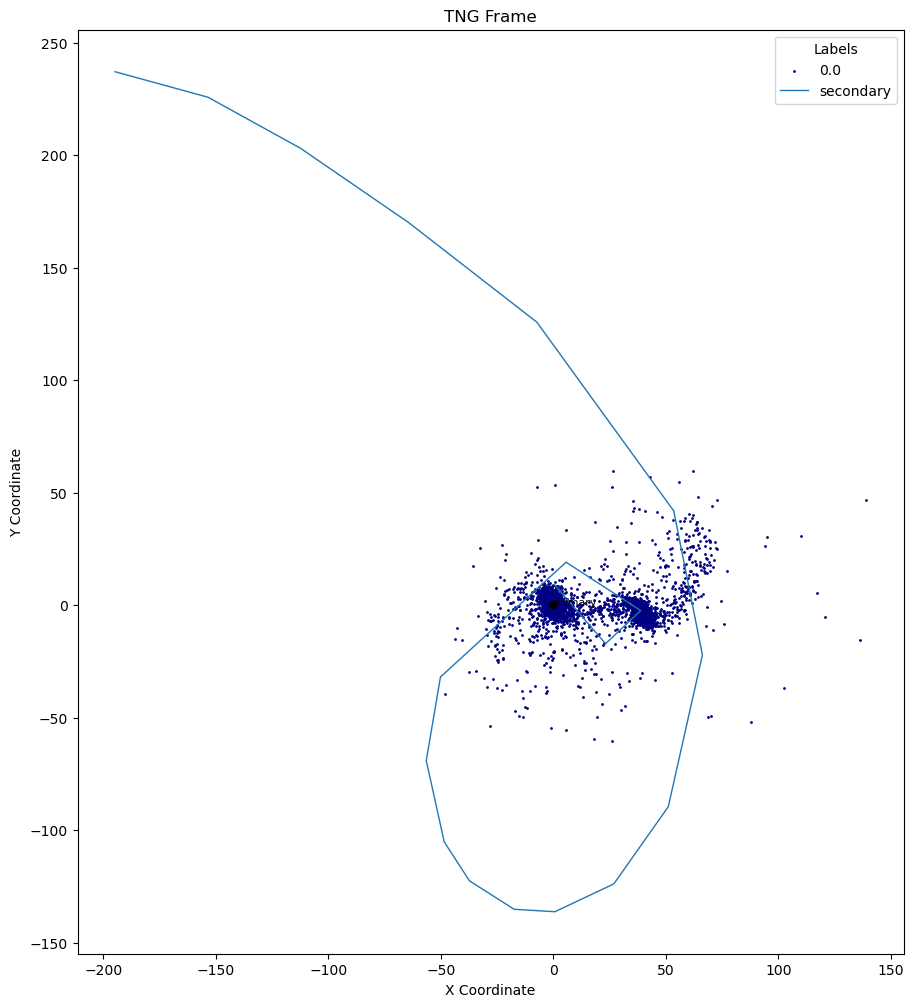

In [12]:
def get_moving_path( t_row, t_df, dev_print = False ):

    LOGGER.debug("Getting TNG orbit...")

    # Get the final position and velocity in frame
    p_pos = t_row['p_SubhaloPos_orbital_frame']
    s_pos = t_row['s_SubhaloPos_orbital_frame']
    p_vel = t_row['p_SubhaloVel_orbital_frame']
    s_vel = t_row['s_SubhaloVel_orbital_frame']

    # Get the tranform needed to convert to orbital frame
    pos_transform = t_row['orbital_frame_pos_transform']
    vel_transform = t_row['orbital_frame_vel_transform']

    # Get raw position and velocity data
    p_path_raw_pos = np.stack(t_df['p_SubhaloPos'].values)
    s_path_raw_pos = np.stack(t_df['s_SubhaloPos'].values)
    p_path_raw_vel = np.stack(t_df['p_SubhaloVel'].values)
    s_path_raw_vel = np.stack(t_df['s_SubhaloVel'].values)

    if dev_print:

        print(f"positions type: {type(p_pos)}")
        print(f"Primary Position: {p_pos}")
        print(f"Secondary Position: {s_pos}")
        print(f"Primary Velocity: {p_vel}")
        print(f"Secondary Velocity: {s_vel}")

        print( f"tranform type: {type(pos_transform)}" )
        print( f"Position Transform: \n{pos_transform}" )
        print( f"Velocity Transform: \n{vel_transform}" )

        print( f"Raw Position Type: {type(p_path_raw_pos)}" )
        print( f"Raw Position Data: {p_path_raw_pos.shape}" )
        print( f"Raw Velocity Data: {p_path_raw_vel.shape}" )
    
    p_path_pos = tf.apply_transformation( pos_transform, p_path_raw_pos )
    s_path_pos = tf.apply_transformation( pos_transform, s_path_raw_pos )
    p_path_vel = tf.apply_transformation( vel_transform, p_path_raw_vel )
    s_path_vel = tf.apply_transformation( vel_transform, s_path_raw_vel )

    p_path = np.hstack( [p_path_pos, p_path_vel])
    s_path = np.hstack( [s_path_pos, s_path_vel])

    if dev_print:
        print( f"Transformed Primary Data: {p_path.shape}" )
        print( f"Transformed Secondary Data: {s_path.shape}")
    
    return p_path, s_path

def convert_to_fixed_frame(primary, secondary):
    """
    Convert the orbital paths and velocities to a frame where the primary galaxy is fixed at the origin.

    Args:
    - primary (np.ndarray): Nx6 array of primary galaxy positions and velocities [ x y z vy vy vz ].
    - secondary (np.ndarray): Nx6 array of secondary galaxy positions and velocities [ x y z vy vy vz ].

    Returns:
    - fixed_secondary (np.ndarray): Nx6 array of secondary galaxy positions and velocities in the fixed frame.
    """
    # Ensure the input arrays have the correct shape
    assert primary.shape == secondary.shape

    # Convert to fixed frame
    fixed_secondary = secondary - primary

    return fixed_secondary

def convert_to_moving_frame(primary_moving, secondary_fixed):
    """
    Convert the paths and velocities from a fixed primary frame back to the original moving frame.

    Args:
    - primary_moving (np.ndarray): Nx6 array of primary galaxy positions and velocities [x, y, z, vx, vy, vz].
    - secondary_fixed (np.ndarray): Nx6 array of secondary galaxy positions and velocities in the fixed frame.

    Returns:
    - secondary_moving (np.ndarray): Nx6 array of secondary galaxy positions and velocities in the moving frame.
    """
    # Ensure the input arrays have the correct shape
    assert primary_moving.shape == secondary_fixed.shape, "Primary and fixed secondary arrays must have the same shape"
    assert primary_moving.shape[1] == 6, "Each row should contain 6 elements: [x, y, z, vx, vy, vz]"

    # Convert to moving frame
    secondary_moving = secondary_fixed + primary_moving

    return secondary_moving

if buildEnv and True:

    logger.setLevel(logging.INFO)

    path = {}

    p_path, s_path = get_moving_path( t_row, t_df, dev_print = True )

    path['p_moving'] = p_path
    path['s_moving'] = s_path

    path['s_fixed'] = convert_to_fixed_frame( p_path, s_path )
    pts_tu = tf.apply_transformation( t_row['orbital_frame_pos_transform'], pts_raw )
    pts_tu[:,0:3] = pts_tu[:,0:3] - t_row['p_SubhaloPos_orbital_frame']

    path['snaps'] = np.stack( t_df['snap'].values )
    path['times'] = np.stack( t_df['time_gyr'].values )

    print( pts_tu[:,0:2].shape ) 
    print( pts_tu[:,-2].shape)

    tf.xy_plot( 
        xy_pts = pts_tu[:,0:2],
        plot_lines = path['s_fixed'][7:] , plot_labels=['secondary'], 
        sig_pts=np.array([[0,0,0]]), sig_labels=np.array(['primary']),
        title="TNG Frame", figsize=(12,12), std_dev = 5 )


Time:2025-01-30 11:17:41,987 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...


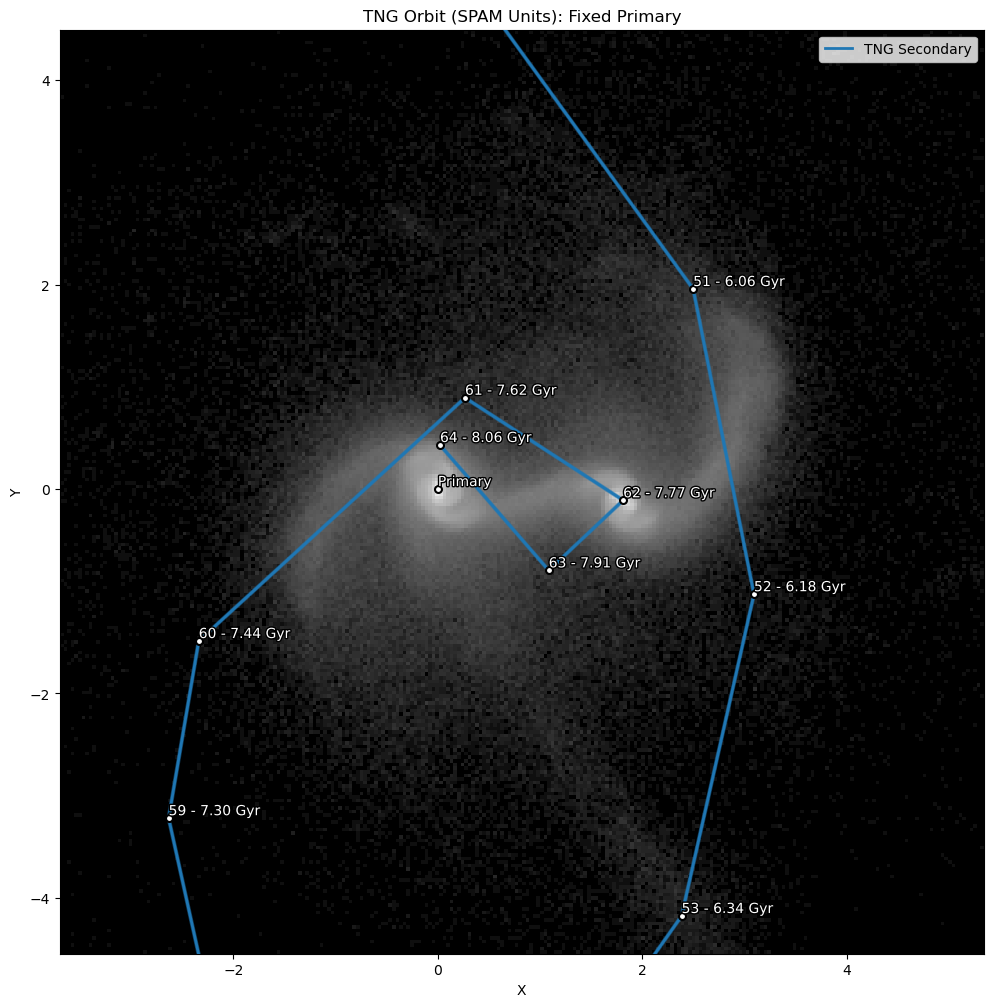

In [13]:
import matplotlib.patheffects as path_effects

def xy_histogram( hist_data,
                plot_data = None, plot_labels = None,
                annotations = None,
                limits = None,
                ext_ax=None,  title="2D Histogram", \
                std_dev=3, bins=256, cmap='gray', \
                log_scale=True, dim_inner = -1, \
                show_labels=False, plotting=True, figsize=None):
    """
    Plots a 2D histogram on a given axis with x and y limits set to n standard deviations.

    Args:
    hist_data (np.ndarray): An N x 2 array of xy coordinates.
    plot_data (list or np.ndarray): Optional. List of N x 2 arrays or a single N x 2 array of xy coordinates to overlay on the histogram.
    plot_labels (list or str): Labels for each plot_data item.
    annotations (list of tuples): List of (location, text) tuples. Each location is an xy coordinate, and text is a string to annotate.
    limits (tuple): Axis limits for x and y.
    ax (matplotlib.axes.Axes or None): The axis to plot on. If None, a new figure and axis will be created.
    title (str): Title of the subplot.
    std_dev (float): Number of standard deviations to set axis limits.
    bins (int): Number of bins along each axis in the histogram.
    cmap (str): Colormap for the histogram.
    log_scale (bool): Whether to apply logarithmic scaling to the histogram.
    dim_inner (int): Threshold for capping high histogram bin counts.
    show_labels (bool): Whether to show axis labels.
    plotting (bool): If true, shows the plot.
    """

    LOGGER.info("Plotting 2D Histogram...")
    LOGGER.debug("Hist Data %s", str(hist_data.shape))

    if hist_data is None:
        LOGGER.error("hist_data cannot be None")
        raise ValueError("hist_data cannot be None")
    

    # Ensure plot_data and plot_labels are lists
    if plot_data is not None and not isinstance(plot_data, list):
        plot_data = [plot_data]
    if plot_labels is not None and not isinstance(plot_labels, list):
        plot_labels = [plot_labels]


    # If ax is None, create a new figure and axis
    ax = ext_ax or plt.subplots(figsize=figsize)[1]

    # Calculate the mean and standard deviation
    mean_xy = np.mean(hist_data[:, 0:2], axis=0)
    std_xy  = np.std( hist_data[:, 0:2], axis=0)

    # Determine the maximum range to use for both axes
    max_range = np.max(std_xy) * std_dev

    # Set axis limits to be the same for both x and y
    if limits is None:
        xlim = (mean_xy[0] - max_range, mean_xy[0] + max_range)
        ylim = (mean_xy[1] - max_range, mean_xy[1] + max_range)
    else:
        xlim = limits[0]
        ylim = limits[1]

    # Create the histogram
    h, xedges, yedges, image = ax.hist2d(hist_data[:, 0], hist_data[:, 1], bins=bins, range=[xlim, ylim], cmap=cmap)
    
    # 
    if dim_inner != -1:
        
        # Calculate the mean and standard deviation of the histogram bin counts
        mean_bin_count = np.mean(h)
        std_bin_count = np.std(h)

        # Set a threshold to cap the brightest regions
        threshold = mean_bin_count + dim_inner * std_bin_count  # You can adjust this multiplier

        # Apply the threshold to cap the values in the histogram
        h[h > threshold] = threshold  # Cap all bin counts above the threshold

    
    # Apply log1p to enhance visibility of low count regions
    if log_scale:
        h = np.log1p(h)  

    # Clear the axis and plot with modified histogram data
    ax.clear()
    image2 = ax.imshow(h.T, interpolation='nearest', origin='lower', aspect='auto',
                      extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                      cmap=cmap)
    
    # Plot each set of plot_data with a unique color and label
    if plot_data is not None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(plot_data)))  # Choose colors from tab10 colormap
        for i, data in enumerate(plot_data):
            label = plot_labels[i] if plot_labels and i < len(plot_labels) else f"Data {i+1}"
            ax.plot(data[:, 0], data[:, 1], color=colors[i], linewidth=2, zorder=5, label=label)
            ax.plot(data[:, 0], data[:, 1], color=colors[i], linewidth=3, zorder=4, alpha=0.5)

        # Show legend
        ax.legend()
    
    # Annotate data points with large white points and text with a black outline
    if annotations is not None:
        for location, text in annotations:
            # Check if the annotation is within the plot bounds
            if xlim[0] <= location[0] <= xlim[1] and ylim[0] <= location[1] <= ylim[1]:
                ax.scatter(*location, color='white', s=25, edgecolor='black', linewidth=1.5, zorder=6)  # Large white point with black outline
                text_obj = ax.text(location[0], location[1], text, fontsize=10, color='white',
                                ha='left', va='bottom', zorder=7)
                # Apply a black outline to text
                text_obj.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])


    # Set titles and labels
    ax.set_title(title)
    
    if show_labels:
        # Add axis labels and ticks (they are no longer removed)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')

    else:   
        # Remove the axis labels and ticks
        ax.set_xticks([])
        ax.set_yticks([])
    
    ax.legend()

    # Set axis limits
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')

    # If ax was None, display the plot
    if ax is None:
        plt.show()

    # Enforce square aspect ratio
    ax.set_aspect('equal')
    
    return

if buildEnv and True:

    # convert tng pts to spam units
    pts_su = np.copy( pts_raw )
    pts_su[:,0:3] = convert_distance_tng_to_spam( pts_tu[:,0:3] )
    pts_su[:,3:6] = convert_velocity_tng_to_spam( pts_tu[:,3:6] )

    # Convert the paths to SPAM units
    path['p_moving_su'] = np.copy( path['p_moving'] )
    path['p_moving_su'][:,0:3] = convert_distance_tng_to_spam( path['p_moving'][:,0:3] )
    path['p_moving_su'][:,3:6] = convert_velocity_tng_to_spam( path['p_moving'][:,3:6] )
    path['s_moving_su'] = np.copy( path['s_moving'] )
    path['s_moving_su'][:,0:3] = convert_distance_tng_to_spam( path['s_moving'][:,0:3] )
    path['s_moving_su'][:,3:6] = convert_velocity_tng_to_spam( path['s_moving'][:,3:6] )
    path['s_fixed_su'] = np.copy( path['s_fixed'] )
    path['s_fixed_su'][:,0:3] = convert_distance_tng_to_spam( path['s_fixed'][:,0:3] )
    path['s_fixed_su'][:,3:6] = convert_velocity_tng_to_spam( path['s_fixed'][:,3:6] )
    path['times_su'] = convert_time_tng_to_spam( path['times'] )

    # Create list of tuples from secondary fixed path and snap data
    base_annotate_data = [(path['s_fixed_su'][i, 0:2], f"{path['snaps'][i]} - {path['times'][i]:.2f} Gyr") for i in range(len(path['snaps']))]

    # Add origin as primary galaxy
    base_annotate_data.append( ([0,0], 'Primary') )

    xy_histogram( \
        pts_su, \
        path['s_fixed_su'], 'TNG Secondary', \
        show_labels = True, std_dev = 4,
        annotations = base_annotate_data,
        title = 'TNG Orbit (SPAM Units): Fixed Primary',
        figsize=(12,12)
    )

## Creating Splines

So, I want to study the TNG orbit between snapshots, specifically the moments of closest approach aka fly-by events.  Splines are a common way to interpolate between points, so let's create a spline for the TNG data. 


In [14]:


if buildEnv and False:

    # Send to histogram 
    xy_histogram( \
        pts_su, \
        path['s_fixed_su_cubic_nat_test'], 'TNG Orbit - Fixed Primary\nNatural Cubic Spline', \
        show_labels = True, std_dev = 4,
        annotations= base_annotate_data,
        title = 'TNG Orbit (SPAM Units): Fixed Primary - Natural Cubic Spline',
        figsize=(12,12)
    )


Time:2025-01-30 11:17:43,414 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...
Time:2025-01-30 11:17:43,890 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...


Time:2025-01-30 11:17:44,282 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...


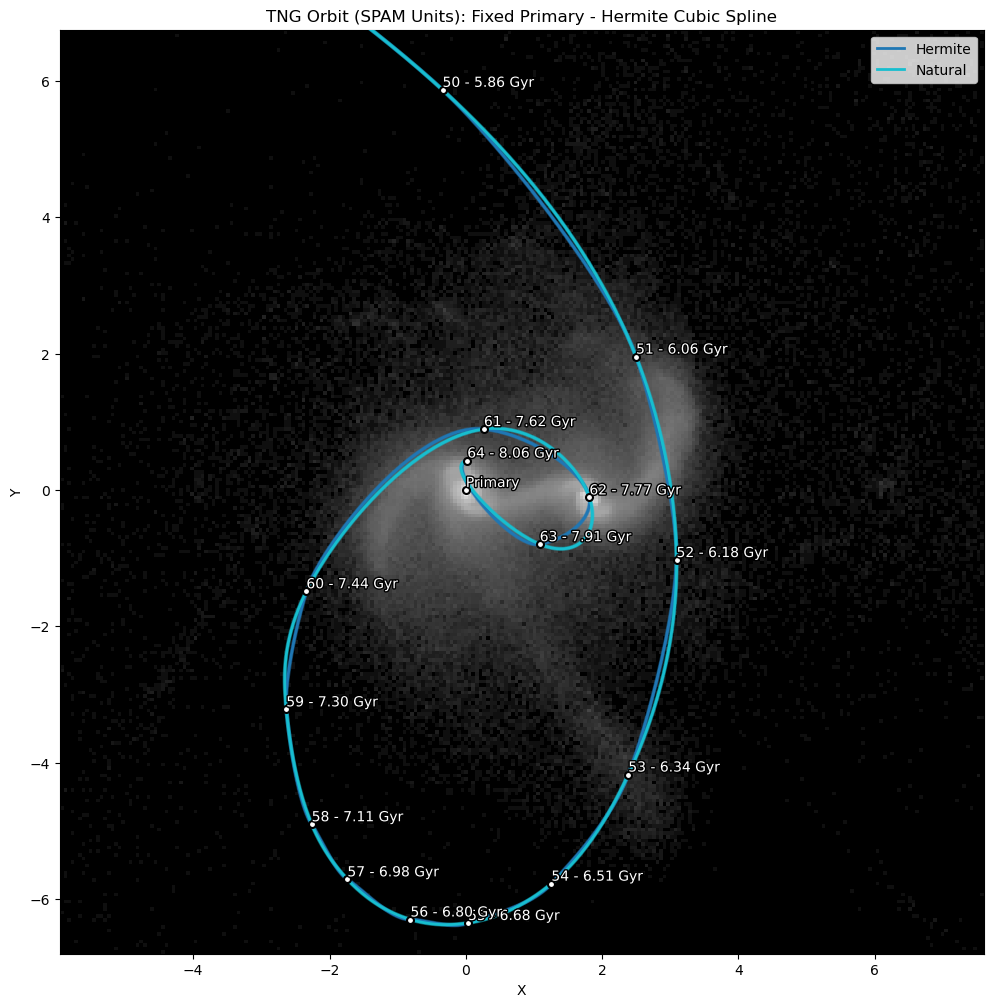

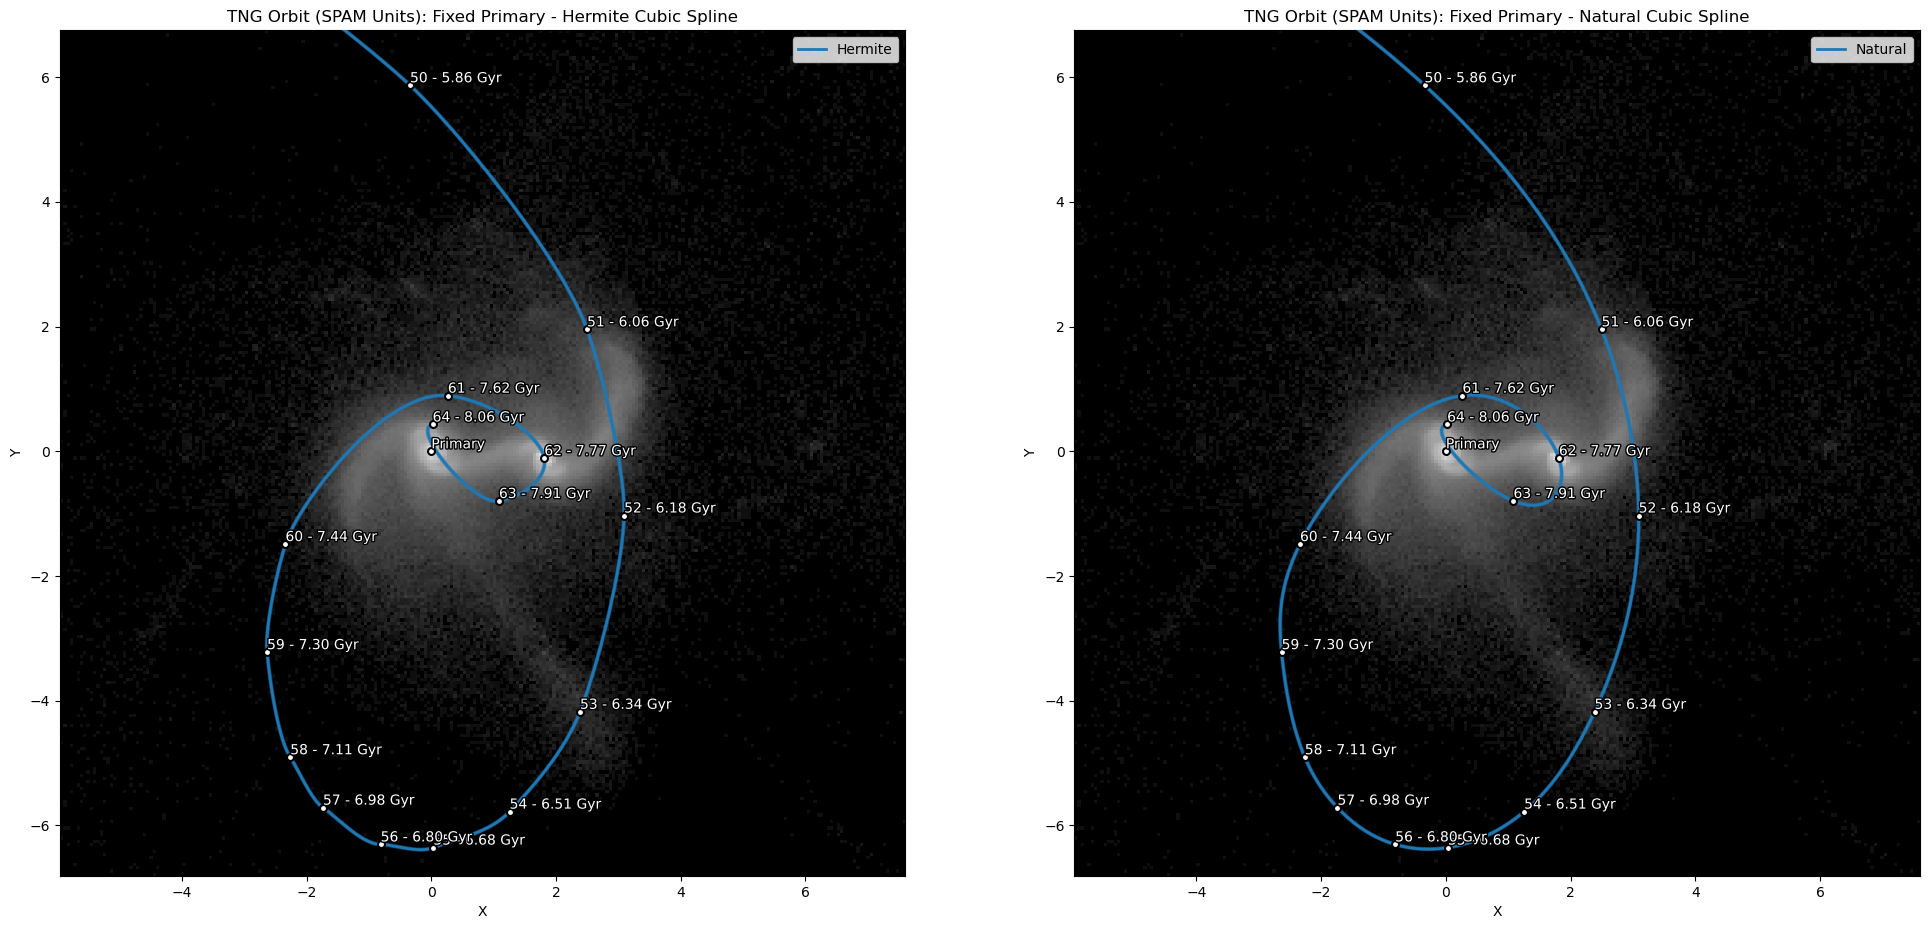

In [15]:
def interpolate_path_natural_cubic(times, path):

    LOGGER.debug("Interpolating path with natural cubic splines...")

    # Extract positions and velocities
    x, y, z = path[:, 0], path[:, 1], path[:, 2]
    dx, dy, dz = path[:, 3], path[:, 4], path[:, 5]

    # Create cubic splines with clamped boundary conditions using endpoint velocities
    spline_x = CubicSpline(times, x, bc_type=((1, dx[0]), (1, dx[-1])))
    spline_y = CubicSpline(times, y, bc_type=((1, dy[0]), (1, dy[-1])))
    spline_z = CubicSpline(times, z, bc_type=((1, dz[0]), (1, dz[-1])))

    # Add the splines and their derivative functions to a list
    splines = [spline_x, spline_y, spline_z, spline_x.derivative(), spline_y.derivative(), spline_z.derivative()]

    return splines


def interpolate_path_with_velocities(times, path):

    LOGGER.debug("Interpolating path with Hermite cubic splines...")

    # Separate positions and velocities into x, y, z components
    x, y, z = path[:, 0], path[:, 1], path[:, 2]
    dx, dy, dz = path[:, 3], path[:, 4], path[:, 5]

    # Create Hermite splines for each dimension
    spline_x = CubicHermiteSpline(times, x, dx)
    spline_y = CubicHermiteSpline(times, y, dy)
    spline_z = CubicHermiteSpline(times, z, dz)

    # Create list of splines and their derivative functions
    splines = [spline_x, spline_y, spline_z, spline_x.derivative(), spline_y.derivative(), spline_z.derivative()]

    return splines

if buildEnv and True:
    
    # Create cubic splines
    path['s_fixed_su_cubic_nat_func'] = interpolate_path_natural_cubic(path['times_su'], path['s_fixed_su'])

    # Generate a test set of times
    path['s_times_test'] = np.linspace( path['times_su'][0], path['times_su'][-1], 1000 )

    # Evaluate the splines at the test times
    path['s_fixed_su_cubic_nat_test'] = np.array([ [spline(t) for spline in path['s_fixed_su_cubic_nat_func']] for t in path['s_times_test'] ])


    path['s_fixed_su_cubic_herm_func'] = interpolate_path_with_velocities(path['times_su'], path['s_fixed_su'])
    path['s_fixed_su_cubic_herm_test'] = np.array([ [spline(t) for spline in path['s_fixed_su_cubic_herm_func']] for t in path['s_times_test'] ])

    plots = [path['s_fixed_su_cubic_herm_test'],path['s_fixed_su_cubic_nat_test']]
    plot_labels = ['Hermite', 'Natural']

    
    base_plot_list = [path['s_fixed_su_cubic_herm_test']]
    base_plot_labels = ['Hermite']
    sd = 6

    # # Send to histogram 
    xy_histogram( \
        pts_su, \
        plots, plot_labels, \
        show_labels = True, std_dev = sd,
        annotations= base_annotate_data,
        title = 'TNG Orbit (SPAM Units): Fixed Primary - Hermite Cubic Spline',
        figsize=(12,12)
    )
    
    # Create two subplots left and right
    fig, axs = plt.subplots(1, 2, figsize=(24, 12))
    
    # Feed one plot to each subplot with the same pts data
    xy_histogram( \
        pts_su, \
        plots[0], plot_labels[0], \
        show_labels = True, std_dev = sd,
        annotations= base_annotate_data,
        title = 'TNG Orbit (SPAM Units): Fixed Primary - Hermite Cubic Spline',
        ext_ax = axs[0]
    )

    xy_histogram( \
        pts_su, \
        plots[1], plot_labels[1], \
        show_labels = True, std_dev = sd,
        annotations= base_annotate_data,
        title = 'TNG Orbit (SPAM Units): Fixed Primary - Natural Cubic Spline',
        ext_ax = axs[1]
    )


## Analysing Splines

According to ChatGPT, Hermites require positions and velocities to be perfect matches, but this makes the curve look unnatural to me, like it's focusing on connecting dots. It might be using abrupt changes in accelatation to accomplish this.  Natural cubic's on the other hand, do their best to minimize acceleration and thus smooths velocity and acceleration.  Which makes it look intuitively smoother but it does make the velocity data less accurate for a few points.  I also played around with estimating accelerations and creating a quintic spline...  This was even jerkier and worse than the hermite....

Thankfully, while directly comparing the Hermite and natural spline, there does not appear to be any large differences in position/velocity (Except at the very end when they merge, and accelerations are crazy.  Which is not a focus).  And given the spline is an interpolation in the first place, there will always be a bit of error between points no matter which inpertoloation I use. 

**(NO MORE SPLINES MATTHEW)**
---
---

In [16]:
if buildEnv:
    
    base_plot_list = [path['s_fixed_su_cubic_herm_test']]
    base_plot_labels = ['Hermite']

# Wrapper for TNG to SPAM conversion
Since all the above was tedious, let's automate all of it into a single function before continuing.  

Loaded Pts: (1519823, 10)


Time:2025-01-30 11:17:50,524 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...


Loaded Pts: (2389408, 10)
Done


Time:2025-01-30 11:17:50,850 - [2561079244.xy_histogram] - INFO - Plotting 2D Histogram...


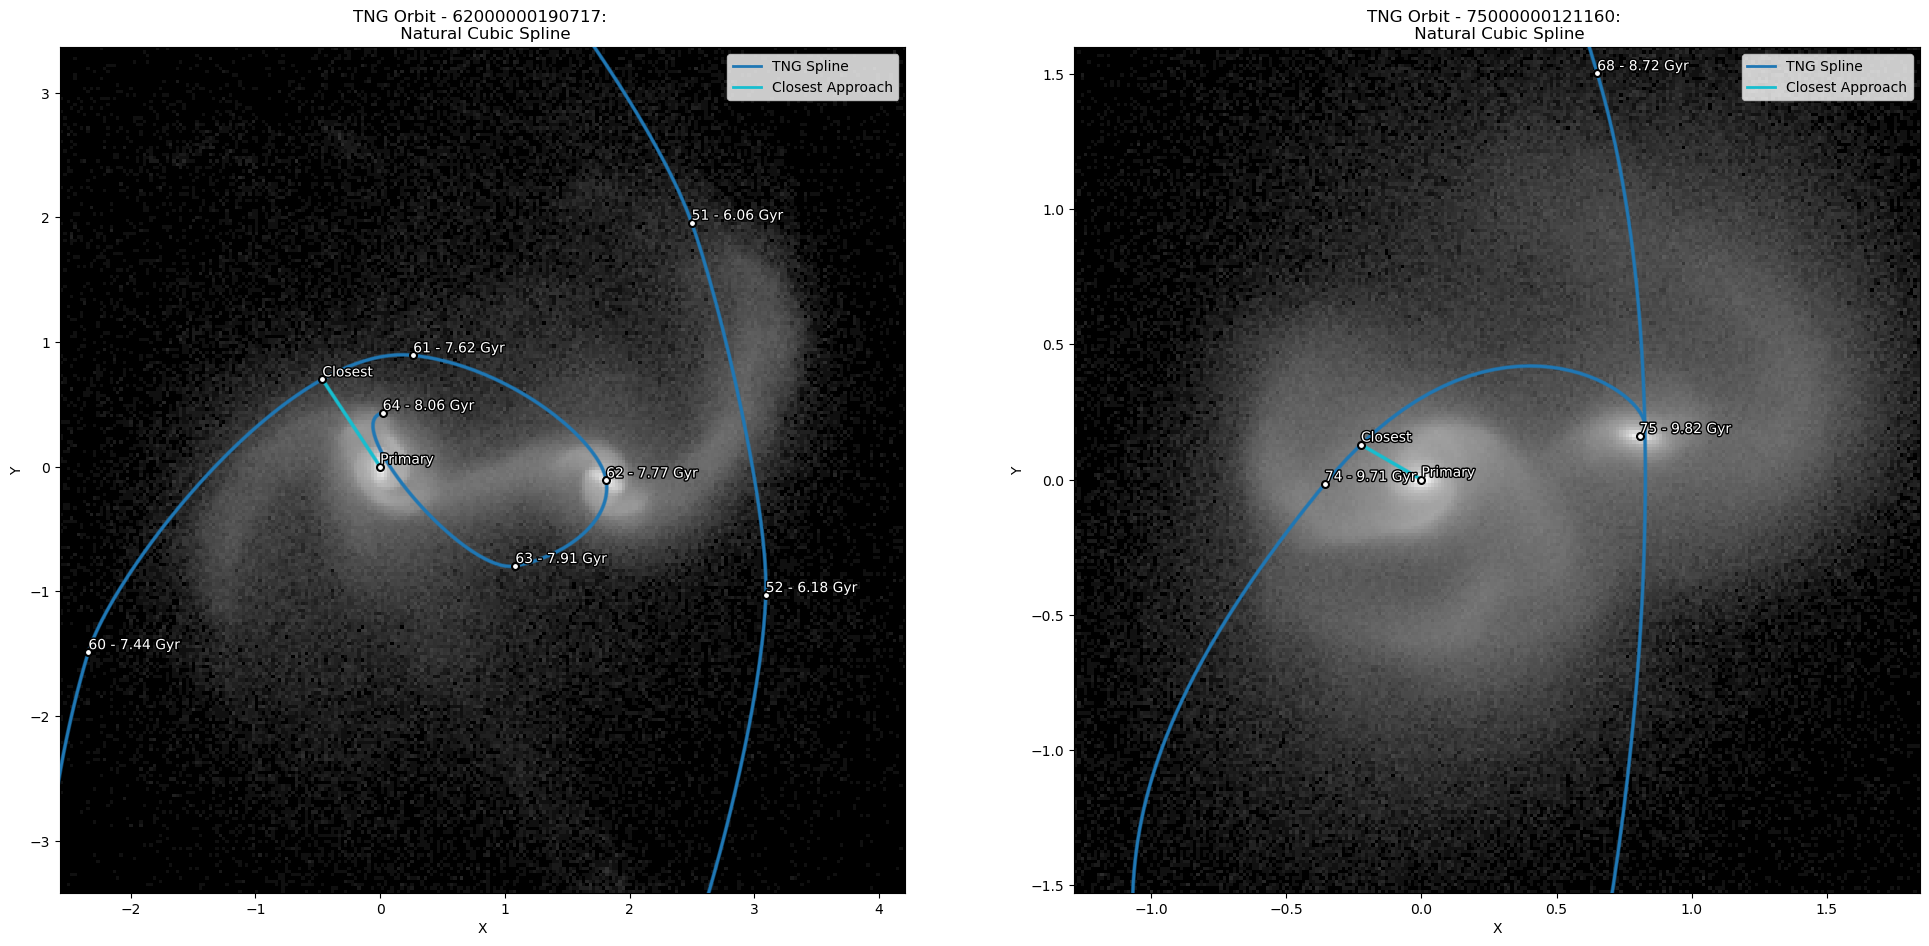

In [17]:
def get_tng_target_orbit( p_id, 
                      file_path = '/home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/tng-targets/moi-4-targets.pkl',
                      dev_print = False,
                      use_spline = 'hermite',
                      ):
    
    LOGGER.debug("Getting TNG target orbit...: %s", str(p_id))
    
    # Load Target Dynamics over time
    tng_targets = pd.read_pickle( file_path )
    t_row, t_df = extractTargetData( p_id, tng_targets, dev_print = dev_print )

    # Extract path
    p_path, s_path = get_moving_path( t_row, t_df )

    path = {}
    path['p_moving'] = p_path
    path['s_moving'] = s_path
    path['snaps'] = np.stack( t_df['snap'].values )
    path['times'] = np.stack( t_df['time_gyr'].values )
    
    path['current_snap'] = t_row['snap']
    path['current_snap_idx'] = t_row['idx']
    path['current_snap_time'] = t_row['time_gyr']

    path['s_fixed'] = convert_to_fixed_frame( p_path, s_path )

    # Convert the paths to SPAM units
    path['times_su'] = convert_time_tng_to_spam( path['times'] )
    path['p_moving_su'] = np.copy( path['p_moving'] )
    path['p_moving_su'][:,0:3] = convert_distance_tng_to_spam( path['p_moving'][:,0:3] )
    path['p_moving_su'][:,3:6] = convert_velocity_tng_to_spam( path['p_moving'][:,3:6] )
    path['s_moving_su'] = np.copy( path['s_moving'] )
    path['s_moving_su'][:,0:3] = convert_distance_tng_to_spam( path['s_moving'][:,0:3] )
    path['s_moving_su'][:,3:6] = convert_velocity_tng_to_spam( path['s_moving'][:,3:6] )
    path['s_fixed_su'] = np.copy( path['s_fixed'] )
    path['s_fixed_su'][:,0:3] = convert_distance_tng_to_spam( path['s_fixed'][:,0:3] )
    path['s_fixed_su'][:,3:6] = convert_velocity_tng_to_spam( path['s_fixed'][:,3:6] )
    
    # Create Splines for plotting
    path['s_fixed_su_cubic_herm_func'] = interpolate_path_with_velocities(path['times_su'], path['s_fixed_su'])
    path['s_fixed_su_cubic_nat_func'] = interpolate_path_natural_cubic(path['times_su'], path['s_fixed_su'])
    path['s_times_test'] = np.linspace( path['times_su'][0], path['times_su'][-1], 1000 )
    path['s_fixed_su_cubic_herm_test'] = np.array([ [spline(t) for spline in path['s_fixed_su_cubic_herm_func']] for t in path['s_times_test'] ])
    path['s_fixed_su_cubic_nat_test'] = np.array([ [spline(t) for spline in path['s_fixed_su_cubic_nat_func']] for t in path['s_times_test'] ])

    # Choose which spline to use
    if use_spline == 'hermite':
        LOGGER.debug("Using Hermite Cubic Spline")
        spline_func = path['s_fixed_su_cubic_herm_func']
        spline_test = path['s_fixed_su_cubic_herm_test']
    elif use_spline == 'natural':
        LOGGER.debug("Using Natural Cubic Spline")
        spline_func = path['s_fixed_su_cubic_nat_func']
        spline_test = path['s_fixed_su_cubic_nat_test']
    else:
        raise ValueError(f"Invalid spline type: {use_spline}")
    
    path['spline_func'] = spline_func
    path['spline_test'] = spline_test

    # Create Spline function for convenience
    def gen_spline_vals( times, tmp_spline = use_spline ):
        if tmp_spline == 'hermite':
            return np.array([ [spline(t) for spline in path['s_fixed_su_cubic_herm_func']] for t in times ])
        elif tmp_spline == 'natural':
            return np.array([ [spline(t) for spline in path['s_fixed_su_cubic_nat_func']] for t in times ])
        
    path['generate_spline'] = gen_spline_vals

    # Using spline tests, Go backwards in time from the current position, and the point of closest to approach
    # This will be the point where the secondary galaxy is closest to the primary galaxy
    current_time = convert_time_tng_to_spam( t_row['time_gyr'] )    # Get current moment in time
    current_idx = np.argmin( np.abs( path['s_times_test'] - current_time ) )    # Find idx for current time
    current_pos = spline_test[current_idx,0:3]     # Get current position
    current_dist = np.linalg.norm( current_pos )    # Get current distance  Note origin is primary galaxy position
    current_time = path['s_times_test'][current_idx]
    
    # While distance descrease, keep going back in time
    moving_idx = current_idx - 1
    prev_dist = current_dist

    # Add condition to continue to move back in time in case they were converging
    keep_moving = True

    # Find most recent location of closest approach
    while True:
        if moving_idx < 0:  break        # Hard break limit
        moving_pos = spline_test[moving_idx,0:3]
        moving_dist = np.linalg.norm( moving_pos )

        # Just in case the galaxies were converging at current time, go backwards until they were diverging after closest approach
        if keep_moving and moving_dist > prev_dist:
            prev_dist = moving_dist
            moving_idx -= 1
            continue
        else:
            keep_moving = False

        # Found the point of closest approach, (Assuming smooth local minima)
        if moving_dist > prev_dist :
            closest_idx = moving_idx
            break

        prev_dist = moving_dist
        moving_idx -= 1
    
    # Just in case the closest approach wasn't smooth, double the time range to ensure we get a good section surrounding the closest approach
    past_idx = current_idx - 2*( current_idx - closest_idx )
    if past_idx < 0: past_idx = 0

    # Using the closest index, get the closest position
    path['current_idx'] = current_idx
    path['current_pos'] = current_pos
    path['current_time'] = current_time
    path['closest_idx'] = closest_idx
    path['closest_pos'] = spline_test[closest_idx,0:3]
    path['closest_time'] = path['s_times_test'][closest_idx]
    path['past_idx'] = past_idx
    path['past_pos'] = spline_test[past_idx,0:3]
    path['past_time'] = path['s_times_test'][past_idx]

    path['past_dt'] = path['closest_time'] - path['past_time']
    path['current_dt'] = path['current_time'] - path['closest_time']

    if dev_print:
        print(f"Test Spline: {spline_test.shape}")
        print(f"Current: {current_idx} - {current_time:.2f}")
        print(f"Closest: {closest_idx} - {path['closest_time']:.2f}")
        print(f"Past: {past_idx} - {path['past_time']:.2f}")
        print(f"Past dt: {path['past_dt']:.2f}")
        print(f"Current dt: {path['current_dt']:.2f}")

    # Starting from current snapshot, go back in time until you find a snapshot before the closest approach
    for i in range( int(path['current_snap_idx']), 0, -1 ):
        t = path['times_su'][i]
        if dev_print: print( f" - {i} - {path['snaps'][i]} - {t:.2f} < {path['closest_time']:.2f}" )
        if t < path['closest_time']:
            j = i-1 # Do two snapshots back to ensure tidal forces are not too strong
            path['snap_before_closest_approach_orbit_idx'] = j
            path['snap_before_closest_approach'] = path['snaps'][j]
            path['snap_before_closest_approach_time'] = path['times_su'][j]
            break  # Break when found
        

    if dev_print:
        print( f"Current: {t_row['snap']} - {current_idx} - {current_pos} - {current_time} - " )
        print( f"Closest: {closest_idx} - {path['closest_pos']} - {path['closest_time']}" )
        if path['past_time'] > path['snap_before_closest_approach_time']:
            print( f"Past: {past_idx} - {path['past_pos']} - {path['past_time']}" )
            print( f"Snap Before Closest Approach: {path['snap_before_closest_approach']} - {path['snap_before_closest_approach_time']}" )
        else:
            print( f"Snap Before Closest Approach: {path['snap_before_closest_approach']} - {path['snap_before_closest_approach_time']}" )
            print( f"Past: {past_idx} - {path['past_pos']} - {path['past_time']}" )
    
    # Generate arrays for feeding into spam
    path['tng_ar_v1'] = standardize_tng_parameters_v1( t_row, )
    path['spam_ar_v1'] = convert_units_tng_to_spam( path['tng_ar_v1'] )
    path['tng_ar_v2'] = standardize_tng_parameters_v2( t_df, path['current_snap'], path['snap_before_closest_approach'] )
    path['spam_ar_v2'] = convert_units_tng_to_spam( path['tng_ar_v2'] )

    # Add function for generating new arrays with different radius scales
    def gen_new_spam_arrays( radius_scale = 5.0, ):
        tmp_ar = standardize_tng_parameters_v1( t_row, radius_scale = radius_scale )
        ar_v1 = convert_units_tng_to_spam( tmp_ar )
        tmp_ar = standardize_tng_parameters_v2( t_df, path['current_snap'], path['snap_before_closest_approach'], radius_scale = radius_scale )
        ar_v2 = convert_units_tng_to_spam( tmp_ar )
        return ar_v1, ar_v2
    
    path['generate_spam_array'] = gen_new_spam_arrays

    if dev_print:
        print( f"V1: {path['tng_ar_v1']}" )
        print( f"V2: {path['tng_ar_v2']}" )
        print(f"Diff: {np.sum( np.abs( path['tng_ar_v1'] - path['tng_ar_v2'] ) )}")

    # Create list of tuples to annotate the plot
    base_annotate_data = [(path['s_fixed_su'][i, 0:2], f"{path['snaps'][i]} - {path['times'][i]:.2f} Gyr") for i in range(len(path['snaps']))]
    path['annotations_base'] = base_annotate_data
    path['annotations'] = base_annotate_data.copy()
    path['annotations'].append( ([0,0], 'Primary') )
    path['annotations'].append( (spline_test[closest_idx,0:2], 'Closest') )

    # Create plot []
    path['plot_list_base'] = [spline_test,]
    path['plot_labels_base'] = ['TNG Spline']

    # Add a line between the origin and the closest point
    path['plot_list_base'].append( np.array([ [0,0,0], spline_test[closest_idx,0:3] ]) )
    path['plot_labels_base'].append('Closest Approach')

    # Create new lists for future plotting
    path['plot_list'] = path['plot_list_base'].copy()
    path['plot_labels'] = path['plot_labels_base'].copy()

    # Add the Series and DataFrame to the path for convenience
    path['current_info'] = t_row
    path['all_info'] = t_df

    # Add function for resetting the plot info
    def reset_plot_info():
        path['plot_list'] = path['plot_list_base'].copy()
        path['plot_labels'] = path['plot_labels_base'].copy()
        path['annotations'] = path['annotations_base'].copy()
        return path
    
    path['reset_plot_info'] = reset_plot_info

    return path

def get_tng_target_pts(t_row, p_id = None, dev_print = False,         
           pts_dir = '/home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/tng-data/',
           ):

    if p_id is None:
        p_id = t_row['p_SubhaloIDRaw']

    LOGGER.debug("Getting TNG target pts...: %s", str(p_id))

    # Load Pts
    try:
        pts_raw = load_pts_data( p_id, data_dir = pts_dir )    
        pts_tu = tf.apply_transformation( t_row['orbital_frame_pos_transform'], pts_raw )
        pts_tu[:,0:3] = pts_tu[:,0:3] - t_row['p_SubhaloPos_orbital_frame']
        pts_su = np.copy( pts_tu )
        pts_su[:,0:3] = convert_distance_tng_to_spam( pts_tu[:,0:3] )
        pts_su[:,3:6] = convert_velocity_tng_to_spam( pts_tu[:,3:6] )

        if dev_print:
            print( f"Loaded Pts: {pts_su.shape}" )

        return pts_su
    except:
        return None

if buildEnv:

    # Set logger level
    LOGGER.setLevel(logging.INFO)
    
    # Target Unique IDs
    p1 = 62000000190717 
    p2 = 75000000121160 

    # TNG target data
    tng_target_1 = get_tng_target_orbit( p1, dev_print = False, )
    tng_target_2 = get_tng_target_orbit( p2, dev_print = False )
    
    # TNG Target particles
    tng_target_1['pts'] = get_tng_target_pts( tng_target_1['current_info'], dev_print = True )
    tng_target_2['pts'] = get_tng_target_pts( tng_target_2['current_info'], dev_print = True )

    # Create two subplots left and right
    fig, axs = plt.subplots(1, 2, figsize=(24, 12))

    print("Done")
    
    # Feed one plot to each subplot with the same pts data
    xy_histogram( \
        tng_target_1['pts'], \
        tng_target_1['plot_list'], tng_target_1['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_1['annotations'],
        title = f'TNG Orbit - {tng_target_1["current_info"]["p_SubhaloIDRaw"]}: \n Natural Cubic Spline',
        ext_ax = axs[0]
    )

    xy_histogram( \
        tng_target_2['pts'] , \
        tng_target_2['plot_list'], tng_target_2['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_2['annotations'],
        title = f'TNG Orbit - {tng_target_2["current_info"]["p_SubhaloIDRaw"]}: \n Natural Cubic Spline',
        ext_ax = axs[1]
    )

    plt.show()


In [43]:
from scipy.signal import argrelextrema

class TNG_Target_Dev_Class:
    """
    This class is the interface between IllustrisTNG Target data and the SPAM Galaxy Simulation.
    Since this class started as a dictionary, I will retain dictionary like behavior for older code.
    """
    def __init__(self, tng_primary_id = None, use_spline_type = 'natural', 
                    tng_dynamics_path = '/home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/tng-targets/moi-4-targets.pkl',
                    tng_particle_dir = '/home/mbo2d/galStuff/data/tng-data/',
                    **kwargs):
        
        # initial logger prints
        logger.info("Initializing TNG Target Class...")
        logger.debug("TNG Primary ID: %s", tng_primary_id)
        logger.debug("TNG Dynamics Path: %s", tng_dynamics_path)
        logger.debug("Spline Type: %s", use_spline_type)

        # Save inputs for later use
        self.tng_primary_id = tng_primary_id
        self.__dict__.update(kwargs)
        self.spline_type = use_spline_type

        # Load TNG Targets Data
        self._get_tng_target_dynamics( tng_dynamics_path )

        # Load TNG Target Particles
        self._load_tng_target_particles( tng_particle_dir )

        # Generate Orbits and splines
        self._generate_orbits( use_spline_type )

        # Create info surrounding closest approach
        self._generate_most_recent_closest_approach_info()

        # Generate dynamics/model array of TNG target for SPAM
        _, self.spam_ar = self.generate_target_spam_array()

        # Setup plot defaults
        self._setup_graph_defaults()
    # end of __init__

    def _get_tng_target_dynamics(self, tng_dynamics_path ):

        # Read dynamics data
        try:
            dynamics_df = pd.read_pickle( tng_dynamics_path )
        except FileNotFoundError:
            raise FileReadError("The specified file was not found:")        
        except PermissionError:
            raise FileReadError("Permission denied while accessing the file.")        
        except Exception as e:
            raise FileReadError(f"An unexpected error occurred: {e}")
        
        # Get the row corresponding to the primary galaxy id
        self.current_info, self.all_info = extractTargetData(self.tng_primary_id, dynamics_df,)
    # End of _get_tng_target_dynamics

    def _load_tng_target_particles(self, tng_particle_dir):
        """
        Load TNG Target Particles
        """
        logger.debug("Loading TNG Target Particles...")
        self.pts = get_tng_target_pts( self.current_info, pts_dir = tng_particle_dir )
    # end of _load_tng_target_particles

    def _generate_orbits(self, use_spline_type = 'hermite'):
        """
        Generate the orbits for the TNG Target in different reference frames and units.
        """
        logger.debug("Generating Orbits...")
        log_n_lines = 1

        self.orbit = {}
        p_path, s_path = get_moving_path( self.current_info, self.all_info )
        self.orbit['tng_frame_tng_units'] = {}
        self.orbit['tng_frame_tng_units']['p'] = p_path
        self.orbit['tng_frame_tng_units']['s'] = s_path
        logger.debug( f"TNG Frame: {self.orbit['tng_frame_tng_units']['p'].shape} - {self.orbit['tng_frame_tng_units']['s'].shape}" 
                     + f"\nPrimary:{self.orbit['tng_frame_tng_units']['p'][-log_n_lines:]}" 
                     + f"\nSecondary:{self.orbit['tng_frame_tng_units']['s'][-log_n_lines:]}" )

        # Convert to SPAM frame
        self.orbit['spam_frame_tng_units'] = convert_to_fixed_frame( p_path, s_path )

        # Add Time data to orbit
        self.orbit['spam_frame_tng_units'] = np.hstack( (self.orbit['spam_frame_tng_units'], self.all_info['time_gyr'].values.reshape(-1,1)) )
        logger.debug( f"SPAM Frame - TNG Units: {self.orbit['spam_frame_tng_units'].shape}"
                     + f"\nStart: {self.orbit['spam_frame_tng_units'][0:log_n_lines]}"
                     + f"\nFinal: {self.orbit['spam_frame_tng_units'][-log_n_lines:]}" )

        # Convert to SPAM units
        self.orbit['spam_frame_spam_units'] = np.copy( self.orbit['spam_frame_tng_units'] )
        self.orbit['spam_frame_spam_units'][:,0:3] = convert_distance_tng_to_spam( self.orbit['spam_frame_tng_units'][:,0:3] )
        self.orbit['spam_frame_spam_units'][:,3:6] = convert_velocity_tng_to_spam( self.orbit['spam_frame_tng_units'][:,3:6] )
        self.orbit['spam_frame_spam_units'][:,-1] = convert_time_tng_to_spam( self.orbit['spam_frame_spam_units'][:,-1] )
        logger.debug( f"SPAM Frame - SPAM Units: {self.orbit['spam_frame_spam_units'].shape}"
                     + f"\nStart: {self.orbit['spam_frame_spam_units'][0:log_n_lines]}"
                     + f"\nFinal: {self.orbit['spam_frame_spam_units'][-log_n_lines:]}" )

        # Create spline functions in spam frame and units
        if use_spline_type == 'hermite':
            logger.debug("Using Hermite Cubic Spline")
            self.spline_function = interpolate_path_with_velocities( self.orbit['spam_frame_spam_units'][:,-1], self.orbit['spam_frame_spam_units'] )

        elif use_spline_type == 'natural':
            logger.debug("Using Natural Cubic Spline")
            self.spline_function = interpolate_path_natural_cubic( self.orbit['spam_frame_spam_units'][:,-1], self.orbit['spam_frame_spam_units'] )
        
        else:
            logger.critical(f"Invalid spline type: {use_spline_type}")
            raise ValueError(f"Invalid spline type: {use_spline_type}")

        # Generate function for creating splines
        def generate_tng_spline_orbit( times ):
            spline_orbit = np.array([ [spline(t) for spline in self.spline_function] for t in times ])
            return np.hstack( (spline_orbit, times.reshape(-1,1)) )
        
        self.generate_tng_spline_orbit = generate_tng_spline_orbit
        
        # Generate a test set of times for entire orbit
        n_pts = 10000
        self.spline_times = np.linspace( self.orbit['spam_frame_spam_units'][0,-1], self.orbit['spam_frame_spam_units'][-1,-1], n_pts )
        self.spline_orbit = np.array([ [spline(t) for spline in self.spline_function] for t in self.spline_times ])

        # stack times with orbit
        self.spline_orbit = np.hstack( (self.spline_orbit, self.spline_times.reshape(-1,1)) )
        logger.debug( f"SPLINE 1: (SPAM Frame/Units): {self.spline_orbit.shape}"  
                     + f"\nStart: {self.spline_orbit[0:log_n_lines]}"
                     + f"\nFinal: {self.spline_orbit[-log_n_lines:]}" )


        # stack times with orbit
        self.spline_orbit = self.generate_tng_spline_orbit( self.spline_times )
        logger.debug( f"SPLINE 2: (SPAM Frame/Units): {self.spline_orbit.shape}"  
                     + f"\nStart: {self.spline_orbit[0:log_n_lines]}"
                     + f"\nFinal: {self.spline_orbit[-log_n_lines:]}" )
    # end of _generate_orbits

    def _generate_most_recent_closest_approach_info(self):
        """
        Generate information surrounding the most recent closest approach.
        MOCA: Moment-Of-Closest-Approach
        """

        logger.debug("Generating Most Recent Moment of Closest Approach (MOCA) Info...")
        
        self.moca = {} # Moment Of Closest Approach 

        # Get Info for current, the boundary for the windows around the closest approach
        self.moca['current'] = {}  # Get current moment in time
        self.moca['current']['snap'] = self.current_info['snap']    # Get current snap
        self.moca['current']['snap_idx'] = self.current_info['idx']    # Get current snap idx

        # Find idx in spline orbit closest to current time
        current_idx = np.argmin( np.abs( self.spline_orbit[:,-1] - self.current_info['times_su'] ) )
        self.moca['current']['spline_idx'] = current_idx
        self.moca['current']['pos'] = self.orbit['spam_frame_spam_units'][self.moca['current']['snap_idx'],0:3]
        self.moca['current']['time_su'] = self.spline_orbit[current_idx,-1]
        self.moca['current']['time_tu'] = convert_time_spam_to_tng( self.moca['current']['time_su'] )
        
        logger.debug( f"Current Time: {self.moca['current']['time_tu']:.2f} Gy - Snap: {self.moca['current']['snap']}" )
        logger.debug( f"Current Target - Pos: {self.moca['current']['pos']}" )
        logger.debug( f"Current Spline - Pos: {self.spline_orbit[current_idx,0:3]}" )

        # Find index of spline where orbit is closest to the primary galaxy (origin) before current time
        seperation_dist = np.linalg.norm( self.spline_orbit[:,0:3], axis = 1 )
        minima = argrelextrema( seperation_dist, np.less, order=5 )
        closest_idx = minima[0][ minima[0] < self.moca['current']['spline_idx'] ][-1]

        # Get the closest approach info
        self.moca['closest'] = {}
        self.moca['closest']['spline_idx'] = closest_idx
        self.moca['closest']['pos'] = self.spline_orbit[closest_idx,0:3]
        self.moca['closest']['time_su'] = self.spline_orbit[closest_idx,-1]
        self.moca['closest']['time_tu'] = convert_time_spam_to_tng( self.moca['closest']['time_su'] )

        logger.debug( f"Closest Time: {self.moca['closest']['time_tu']:.2f} Gy" )

        # Get opposite inbound boundary from current time centered on closest time
        diff_idx = self.moca['current']['spline_idx'] - self.moca['closest']['spline_idx']

        self.moca['inbound'] = {}
        self.moca['inbound']['spline_idx'] = self.moca['closest']['spline_idx'] - diff_idx
        self.moca['inbound']['pos'] = self.spline_orbit[self.moca['inbound']['spline_idx'],0:3]
        self.moca['inbound']['time_su'] = self.spline_orbit[self.moca['inbound']['spline_idx'],-1]
        self.moca['inbound']['time_tu'] = convert_time_spam_to_tng( self.moca['inbound']['time_su'] )

        logger.debug( f"Inbound Time: {self.moca['inbound']['time_tu']:.2f} Gy" )

        # Get subsection of spline orbit that captures this window
        self.moca['orbit'] = self.spline_orbit[ self.moca['inbound']['spline_idx']:self.moca['current']['spline_idx']+1 ]
        
        # Save idx for new subsection of orbit
        self.moca['inbound']['idx'] = 0
        self.moca['closest']['idx'] = self.moca['closest']['spline_idx'] - self.moca['inbound']['spline_idx']
        self.moca['current']['idx'] = self.moca['current']['spline_idx'] - self.moca['inbound']['spline_idx']

        logger.debug( f"MOCA Orbit: {self.moca['orbit'].shape}\n{self.moca['orbit'][:2]}\n...\n{self.moca['orbit'][-2:]}" )
        logger.debug( f"MOCA Idx: {self.moca['inbound']['idx']} - {self.moca['closest']['idx']} - {self.moca['current']['idx']}" )

        # Lastly, Get idx of the closest snapshot before the inbound time
        self.moca['inbound']['snap_idx'] = len( self.all_info['times_su'][ self.all_info['times_su'] < self.moca['inbound']['time_su']] )-1
        self.moca['inbound']['snap'] = self.all_info['snap'].values[self.moca['inbound']['snap_idx']]
        self.moca['inbound']['snap_time_su'] = self.all_info['times_su'].values[self.moca['inbound']['snap_idx']]
        self.moca['inbound']['snap_time_gyr'] = self.all_info['time_gyr'].values[self.moca['inbound']['snap_idx']]

        logger.debug( f"MOCA Inbound Snap: {self.moca['inbound']['snap']}" )
    # end of _generate_most_recent_closest_approach_info

    def _setup_graph_defaults(self):
        """
        Setup default graph parameters
        """

        # Default plots, TNG splint orbit and vector of closest approach
        self.plot_base = []

        # TNG Spline Orbit
        self.plot_base.append( ( self.spline_orbit, {'color':'white', 'linewidth':1, 'label':'TNG Spline Orbit', 'linestyle': '--'} ) ) 

        # Closest Approach Vector
        self.plot_base.append( ( [ np.zeros(3), self.moca['closest']['pos'] ], {'color':'white', 'linewidth':1, 'label':'MOCA Vector', 'zorder':5} ) )
        self.plot_base.append( ( [ np.zeros(3), self.moca['closest']['pos'] ], {'color':'black', 'linewidth':3, 'zorder':4} ) ) # shadow

        # Default Histogram data
        # Calculate limits from the mean and standard deviation
        mean_pos = np.mean( self.pts[:,0:2], axis=0 )
        std_dev = np.std( self.pts[:,0:2], axis=0 )

        # Determine max range from mean and std_dev
        max_range = np.max( std_dev ) * 3

        hist_style = {'cmap':'gray', 'bins':256, 
                      'range':[(mean_pos[0]-max_range, mean_pos[0]+max_range), (mean_pos[1]-max_range, mean_pos[1]+max_range)], 
                     }
        
        self.base_hist_data = ( self.pts, hist_style )
        
        # Setup default annotations
        self.base_annotations = [ ( pos, f"{self.all_info['snap'][i]}: {self.all_info['time_gyr'][i]:.1f} Gyr"  ) for i, pos in enumerate(self.orbit['spam_frame_tng_units'][:,0:2]) ]
        self.base_annotations.append( ( np.zeros(2), "" ) )# (location, text)
    # end of _setup_plotting_defaults 

    def generate_target_spam_array( self, radius_scale = 5.0, ):
        logger.debug("Generating SPAM arrays with radius scale: %s", radius_scale)
        tmp_ar = standardize_tng_parameters_v1( self.current_info, radius_scale = radius_scale )
        ar_v1 = convert_units_tng_to_spam( tmp_ar )
        tmp_ar = standardize_tng_parameters_v2( self.all_info, self.current_info['snap'], self.moca['inbound']['snap'], radius_scale = radius_scale )
        ar_v2 = convert_units_tng_to_spam( tmp_ar )
        
        return ar_v1, ar_v2
    # end of generate_target_spam_array

    def graph_target(self, ax = None,  overwrite_hist=None, hist_std_dev = 3, log_scale = True,
                     add_annotations = None, overwrite_annotations = None,
                     add_plots = None, overwrite_plots = None, 
                     hard_range = None, show_labels = True,
                     add_spam_orbits = None,
                     **kwargs):
        
        """
        Graph Target Orbit, Particles, and other information
        """

        # Create axis or use given axis
        if ax is None:
            figsize = kwargs.get('figsize', (12,12))
            fig, ax = plt.subplots(1, 1, figsize=figsize)
        
        # If histogram data to use
        if overwrite_hist:
            hist_data = overwrite_hist
        else:
            hist_data = self.base_hist_data
        
        # Set style
        if isinstance(hist_data, tuple):
            hist_data, hist_style = hist_data
        else:
            hist_style = {'cmap':'gray', 'bins':128, } # Default style
        
        # Get annotations to use
        if add_annotations:
            annotations = self.base_annotations.copy()
            annotations.extend( add_annotations )
        elif overwrite_annotations:
            annotations = overwrite_annotations
        else:
            annotations = self.base_annotations
        
        # Get plots to use
        if add_plots:
            plot_list = self.plot_base.copy()
            plot_list.extend( add_plots )
        elif overwrite_plots:
            plot_list = overwrite_plots
        else:
            plot_list = self.plot_base
        
        # Set limits
        if self.base_hist_data[1].get('range', None) is not None:
            # Use base hist limits
            limits = self.base_hist_data[1].pop('range', None)
            xlim = limits[0]
            ylim = limits[1]

        elif hard_range is not None:
            xlim = hard_range[0]
            ylim = hard_range[1]

        else:    
            # Calculate the mean and standard deviation
            mean_xy = np.mean(hist_data[:, 0:2], axis=0)
            std_xy  = np.std( hist_data[:, 0:2], axis=0)

            # Determine the maximum range to use for both axes
            max_range = np.max(std_xy) * std_dev

            # Set axis limits to be the same for both x and y
            if limits is None:
                xlim = (mean_xy[0] - max_range, mean_xy[0] + max_range)
                ylim = (mean_xy[1] - max_range, mean_xy[1] + max_range)

        
        # if given spam orbits to add to graph
        if add_spam_orbits is not None:
            # Ensure it's a list
            if not isinstance(add_spam_orbits, list):
                add_spam_orbits = [add_spam_orbits]

            for i,spam_orbit in enumerate(add_spam_orbits):
                if isinstance(spam_orbit, tuple):
                    spam_orbit, spam_name = spam_orbit
                else:
                    spam_name = 'SPAM Orbit %d' % i
                orbit_info = self.gen_spam_orbit_graph_info( spam_orbit, spam_name )
                plot_list.extend( orbit_info['plot'] )
                annotations.extend( orbit_info['annotations'] )
        
        # Create histogram for reference
        h, xedges, yedges, image = ax.hist2d(hist_data[:, 0], hist_data[:, 1], range=[xlim,ylim], **hist_style)
        ax.clear()

        # Apply log scaling to brightness if requested
        if log_scale: h = np.log1p(h)

        # Now create image from histogram
        img = ax.imshow(h.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
                        origin='lower', cmap=hist_style['cmap'])
        ax.set_aspect('equal')


        # Add plots
        for i,plot_data in enumerate(plot_list):
            
            # If it has additional info
            if isinstance(plot_data, tuple):
                plot_style = plot_data[1]
                plot_data = plot_data[0]
            else:
                plot_style = {'label':'%d' % i, 'linewidth':1}
            
            # If plot data is a list
            if isinstance(plot_data, list):
                plot_data = np.array( plot_data )
            
            ax.plot( plot_data[:,0], plot_data[:,1], **plot_style )
        
        
        # Add annotations 
        for a_loc, a_text in annotations:
            
            # Check if location is inside graph limits
            if xlim[0] < a_loc[0] < xlim[1] and ylim[0] < a_loc[1] < ylim[1]:
            
                ax.scatter( a_loc[0], a_loc[1], s=20, color='w', edgecolor='k', linewidths=1.0, zorder=7 ) # white on black dot
                txt_obj = ax.text( a_loc[0], a_loc[1], a_text, color='w', fontsize=10, zorder=8, ha='left', va='bottom' )
                txt_obj.set_path_effects([path_effects.Stroke(linewidth=1, foreground='black'), path_effects.Normal()])

        if show_labels:
            ax.legend()
        
        # Reset limits to show
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

    # end of _get_tng_target_dynamics

    def gen_spam_orbit_graph_info( self, spam_orbit, spam_run_name = 'SPAM Orbit', graph_info={'plot':[], 'annotations':[]} ):
        """
        Generate graph info for SPAM orbit
        """

        # Create plot tuple
        graph_info['plot'].append((spam_orbit, {'label':spam_run_name, 'linewidth':2}))

        # Always add first Starting position to annotations
        graph_info['annotations'].append( ( spam_orbit[0, 0:2], f"{convert_time_spam_to_tng(spam_orbit[0,-1]):.2f} Gyr") )

        # Find snapshot times.
        for i,t in enumerate(self.all_info['times_su']):

            # Only add times that are within the spam orbit time range
            if t > spam_orbit[0,-1] and t < spam_orbit[-1,-1]:

                # Find index in spam orbit closest to time
                idx = np.argmin(np.abs(spam_orbit[:,-1] - t))

                # Add to annotations
                graph_info['annotations'].append( ( spam_orbit[idx, 0:2], f"{convert_time_spam_to_tng(t):.2f} Gyr") )

        return graph_info

    def __getitem__(self, key):
        return self.__dict__[key]

    def __setitem__(self, key, value):
        self.__dict__[key] = value

if buildEnv:
    logger.setLevel(logging.DEBUG)
    tng_target_test = TNG_Target_Dev_Class( p1, use_spline_type = 'hermite' )
    # test_orbit = tng_target_test.run_orbit_from_param()
    # tng_target_test.graph_target( add_spam_orbits=test_orbit )


Time:2025-01-30 12:07:00,199 - [1183025371.__init__] - INFO - Initializing TNG Target Class...
Time:2025-01-30 12:07:00,200 - [1183025371.__init__] - DEBUG - TNG Primary ID: 62000000190717
Time:2025-01-30 12:07:00,201 - [1183025371.__init__] - DEBUG - TNG Dynamics Path: /home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/tng-targets/moi-4-targets.pkl
Time:2025-01-30 12:07:00,202 - [1183025371.__init__] - DEBUG - Spline Type: hermite
Time:2025-01-30 12:07:00,750 - [1751611623.extractTargetData] - DEBUG - Extracting target data...
Time:2025-01-30 12:07:00,780 - [1183025371._load_tng_target_particles] - DEBUG - Loading TNG Target Particles...
Time:2025-01-30 12:07:00,782 - [99349402.get_tng_target_pts] - DEBUG - Getting TNG target pts...: 62000000190717
Time:2025-01-30 12:07:02,172 - [1183025371._generate_orbits] - DEBUG - Generating Orbits...
Time:2025-01-30 12:07:02,173 - [2130160852.get_moving_path] - DEBUG - Getting TNG orbit...
Time:2025-01-30 12:07:02,176 - [1183025371._generate_orbits] -

<center>
Figure: TNG to SPAM Target Orbit Setup
<center>


---
# TNG to SPAM Orbit Test
---

In [19]:
def add_spam_orbit_info( spam_orbit, tng_target, spam_run_name = 'SPAM Orbit', 
                            add_to_target = False, add_to_base = False,
                            annotations = None,  plot_list = None, plot_labels = None ):

    # If external dicts are not provided, use target plot info
    if annotations is None:
        annotations = tng_target['annotations'].copy()
    if plot_list is None:
        plot_list = tng_target['plot_list'].copy()
    if plot_labels is None:
        plot_labels = tng_target['plot_labels'].copy()

    # If that spam name already exists in the plot labels, remove it and add the new one
    if spam_run_name in plot_labels:
        idx = plot_labels.index( spam_run_name )
        plot_list.pop( idx )
        plot_labels.pop( idx )
    
    # Add Spam orbit to plot list
    plot_list.append( spam_orbit )

    # If name is provided, add to labels
    if spam_run_name is not None:
        plot_labels.append( spam_run_name )
    else:
        plot_labels.append( 'SPAM Orbit' )

    # Always add first Starting position to annotations
    annotations.append( ( spam_orbit[0, 0:2], f"{convert_time_spam_to_tng(spam_orbit[0,-1]):.2f} Gyr") )

    # Find where spam orbit is at snapshot times.
    for i,t in enumerate(tng_target['times_su']):

        # Only add times that are within the spam orbit time range
        if t > spam_orbit[0,-1] and t < spam_orbit[-1,-1]:

             # Find index in spam orbit closest to time
            idx = np.argmin(np.abs(spam_orbit[:,-1] - t))

            # Add to annotations
            annotations.append( ( spam_orbit[idx, 0:2], f"{convert_time_spam_to_tng(t):.2f} Gyr") )

    # If you want to keep this plots around 
    if add_to_target:
        tng_target['annotations'] = annotations
        tng_target['plot_list'] = plot_list
        tng_target['plot_labels'] = plot_labels
    
    # If you want to add these to the base plots
    if add_to_base:
        tng_target['annotations_base'] = annotations
        tng_target['plot_list_base'] = plot_list
        tng_target['plot_labels_base'] = plot_labels
    
    return annotations, plot_list, plot_labels


if buildEnv and False:
    LOGGER.setLevel(logging.DEBUG)
    # Default SPAM simulations of TNG targets
    # These take a while, so only run if needed
    overwrite = True

    # If overwrite, renew tng targets
    if overwrite:
        tng_target_1 = tng_target_1['reset_plot_info']()
        tng_target_2 = tng_target_2['reset_plot_info']()    
        
    if tng_target_1.get('spam_orbit_v1') is None or overwrite:
        tng_target_1['spam_orbit_v1'] = sim.spam_orbit( tng_target_1['spam_ar_v1'], current_time=tng_target_1['current_time'], spam_setup_params={} )
        _ = add_spam_orbit_info( tng_target_1['spam_orbit_v1'], tng_target_1, 'Default Spam Orbit', True, False )

    if tng_target_1.get('spam_orbit_v2') is None or overwrite:
        tng_target_1['spam_orbit_v2'] = sim.spam_orbit( tng_target_1['spam_ar_v2'], current_time=tng_target_1['current_time'], spam_setup_params={} )
        _ = add_spam_orbit_info( tng_target_1['spam_orbit_v2'], tng_target_1, 'TNG_1_SPAM_V2', True, False )

    if tng_target_2.get('spam_orbit_v1') is None or overwrite:
        tng_target_2['spam_orbit_v1'] = sim.spam_orbit( tng_target_2['spam_ar_v1'], current_time=tng_target_2['current_time'], spam_setup_params={} )
        _ = add_spam_orbit_info( tng_target_2['spam_orbit_v1'], tng_target_2, 'TNG_2_SPAM_V1', True, True )

    if tng_target_2.get('spam_orbit_v2') is None or overwrite:
        tng_target_2['spam_orbit_v2'] = sim.spam_orbit( tng_target_2['spam_ar_v2'], current_time=tng_target_2['current_time'], spam_setup_params={} )
        _ = add_spam_orbit_info( tng_target_2['spam_orbit_v2'], tng_target_2, 'Default SPAM Orbit', True, True )

    # Plot the new orbits

    plt.clf()

    xy_histogram( \
        tng_target_1['pts'], \
        tng_target_1['plot_list'], tng_target_1['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_1['annotations'],
        title = f'Target 1 - {tng_target_1["current_info"]["p_SubhaloIDRaw"]}\nDefault SPAM Parameters',
        # figsize=(12,12),
        figsize=(8,8),
    )
    
    plt.show()

    # clear plot for another plot
    plt.clf()

    xy_histogram( \
        tng_target_2['pts'] , \
        tng_target_2['plot_list'], tng_target_2['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_2['annotations'],
        title = f'Target 2 - {tng_target_2["current_info"]["p_SubhaloIDRaw"]}\nDefault SPAM Parameters',
        # figsize=(12,12),
        figsize=(8,8),
    )
    plt.show()


Time:2025-01-30 11:17:54,830 - [152428813.__init__] - INFO - Initializing TNG Target Class...


Time:2025-01-30 11:17:56,801 - [new_simulator.spam_orbit] - INFO - Running SPAM Simulation - Orbit Run
Time:2025-01-30 11:17:56,802 - [new_simulator.set_spam_parameters] - INFO - Setting SPAM Parameters: 


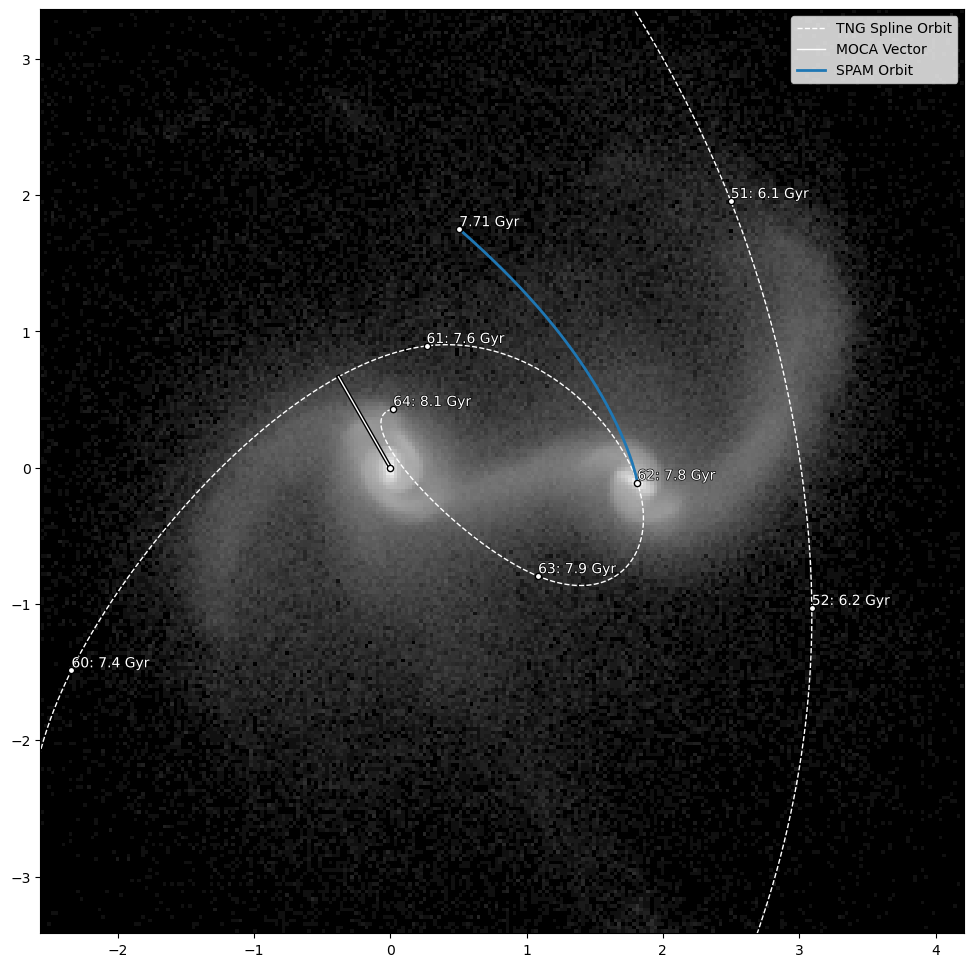

In [20]:
def run_orbit_from_param( self, spam_setup_params = {}, spam_ar = None ):

    # If spam_ar is not provided, use the current spam_ar
    if spam_ar is None:
        spam_ar = self.spam_ar
    
    # Run the orbit
    spam_orbit = sim.spam_orbit( spam_ar, current_time=self.current_info['times_su'], spam_setup_params=spam_setup_params )

    return spam_orbit

setattr(TNG_Target_Dev_Class, 'run_orbit_from_param', run_orbit_from_param)

# setattr( TNG_Target_Dev_Class, 'gen_spam_orbit_graph_info', gen_spam_orbit_graph_info )

if buildEnv:

    # Set logger level to INFO
    LOGGER.setLevel(logging.INFO)

    # Create new instance with new function
    test_target = TNG_Target_Dev_Class( p1 )
    test_orbit = test_target.run_orbit_from_param()
    test_graph_info = test_target.gen_spam_orbit_graph_info( test_orbit )
    test_target.graph_target( add_plots = test_graph_info['plot'], add_annotations = test_graph_info['annotations'] )

    # Add to plot
    # test_target.graph_target( add_plots = [(test_orbit, {'label':'Test Orbit', 'linewidth':2})] )


---
---
# TNG to SPAM Conversion Analysis

Looking at the TNG orbit and SPAM orbit from TNG parameters, we can see the orbits have roughly the same shape, but do not appear to overlap well.   Target 2 does better, but it's concerning how much they do not overlap.  

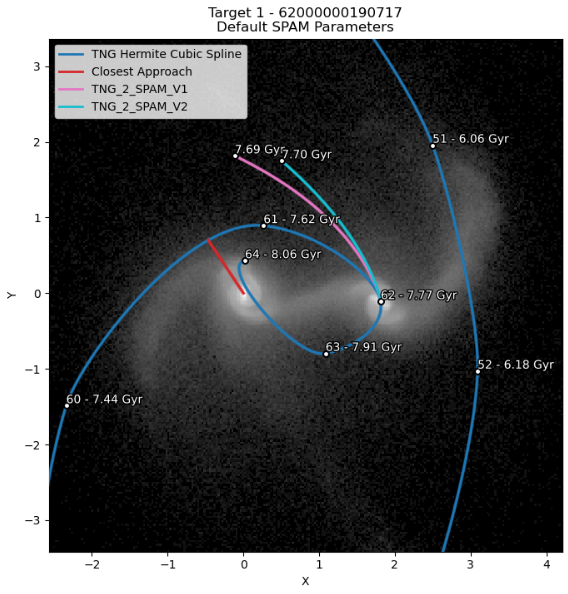
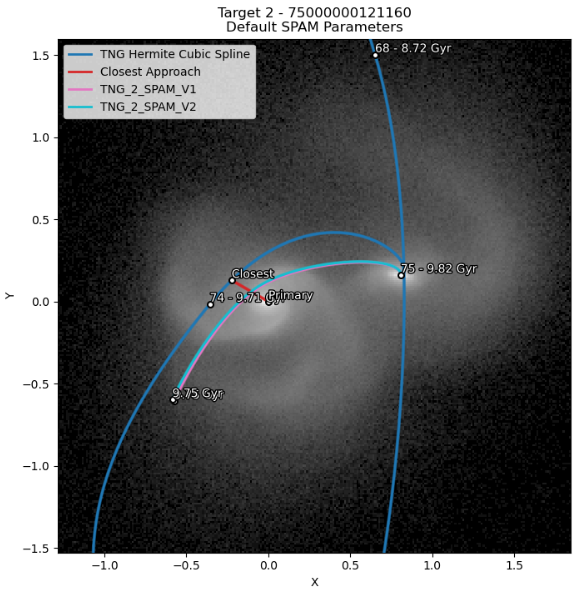


Let's see how well the tidal features match up.
---
---
---

In [21]:
if buildEnv and False:

    # Let's have SPAM simulate some particles and see if they overlap.
    # This will take a while, so only run if needed
    overwrite = True
    n_pts = 10000
    if tng_target_1.get('spam_pts_f_v1') is None or overwrite:
        tng_target_1['spam_pts_i_v1'], tng_target_1['spam_pts_f_v1'] = sim.basic_run( tng_target_1['spam_ar_v1'], npts1=n_pts, npts2=n_pts, spam_setup_params={} )
    
    if tng_target_1.get('spam_pts_f_v2') is None or overwrite:
        tng_target_1['spam_pts_i_v2'], tng_target_1['spam_pts_f_v2'] = sim.basic_run( tng_target_1['spam_ar_v2'], npts1=n_pts, npts2=n_pts, spam_setup_params={} )
    
    # Print pt info
    print( f"SPAM Points: {tng_target_1['spam_pts_f_v1'].shape}" )

    # Create three side by side plots
    fig, axs = plt.subplots(1, 3, figsize=(24, 12))

    # TNG points
    xy_histogram( \
        tng_target_1['pts'], \
        tng_target_1['plot_list'], tng_target_1['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_1['annotations'],
        title = f'Target 1 - {tng_target_1["current_info"]["p_SubhaloIDRaw"]}\nTNG Tidal Features',
        ext_ax = axs[0]
    )

    # SPAM points v1
    xy_histogram( \
        tng_target_1['spam_pts_f_v1'], \
        tng_target_1['plot_list'], tng_target_1['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_1['annotations'],
        title = f'Target 1 - {tng_target_1["current_info"]["p_SubhaloIDRaw"]}\nSPAM Tidal Features v1',
        ext_ax = axs[1]
    )

    # SPAM points v2
    xy_histogram( \
        tng_target_1['spam_pts_f_v2'], \
        tng_target_1['plot_list'], tng_target_1['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_1['annotations'],
        title = f'Target 1 - {tng_target_1["current_info"]["p_SubhaloIDRaw"]}\nSPAM Tidal Features v2',
        ext_ax = axs[2]
    )

    plt.show()

    # Do the same for target 2
    if tng_target_2.get('spam_pts_f_v1') is None or overwrite:
        tng_target_2['spam_pts_i_v1'], tng_target_2['spam_pts_f_v1'] = sim.basic_run( tng_target_2['spam_ar_v1'], npts1=n_pts, npts2=n_pts )
    
    if tng_target_2.get('spam_pts_f_v2') is None or overwrite:
        tng_target_2['spam_pts_i_v2'], tng_target_2['spam_pts_f_v2'] = sim.basic_run( tng_target_2['spam_ar_v2'], npts1=n_pts, npts2=n_pts )
    
    # Clear previous plot
    plt.clf()

    # Create three side by side plots
    fig, axs = plt.subplots(1, 3, figsize=(24, 12))

    # TNG points
    xy_histogram( \
        tng_target_2['pts'], \
        tng_target_2['plot_list'], tng_target_2['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_2['annotations'],
        title = f'Target 2 - {tng_target_2["current_info"]["p_SubhaloIDRaw"]}\nTNG Tidal Features',
        ext_ax = axs[0]
    )

    # SPAM points v1
    xy_histogram( \
        tng_target_2['spam_pts_f_v1'], \
        tng_target_2['plot_list'], tng_target_2['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_2['annotations'],
        title = f'Target 2 - {tng_target_2["current_info"]["p_SubhaloIDRaw"]}\nSPAM Tidal Features v1',
        ext_ax = axs[1]
    )

    # SPAM points v2
    xy_histogram( \
        tng_target_2['spam_pts_f_v2'], \
        tng_target_2['plot_list'], tng_target_2['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_2['annotations'],
        title = f'Target 2 - {tng_target_2["current_info"]["p_SubhaloIDRaw"]}\nSPAM Tidal Features v2',
        ext_ax = axs[2]
    )

Time:2025-01-30 11:18:01,385 - [152428813.__init__] - INFO - Initializing TNG Target Class...


Time:2025-01-30 11:18:03,504 - [new_simulator.basic_run] - INFO - Running SPAM Simulation - Basic Run


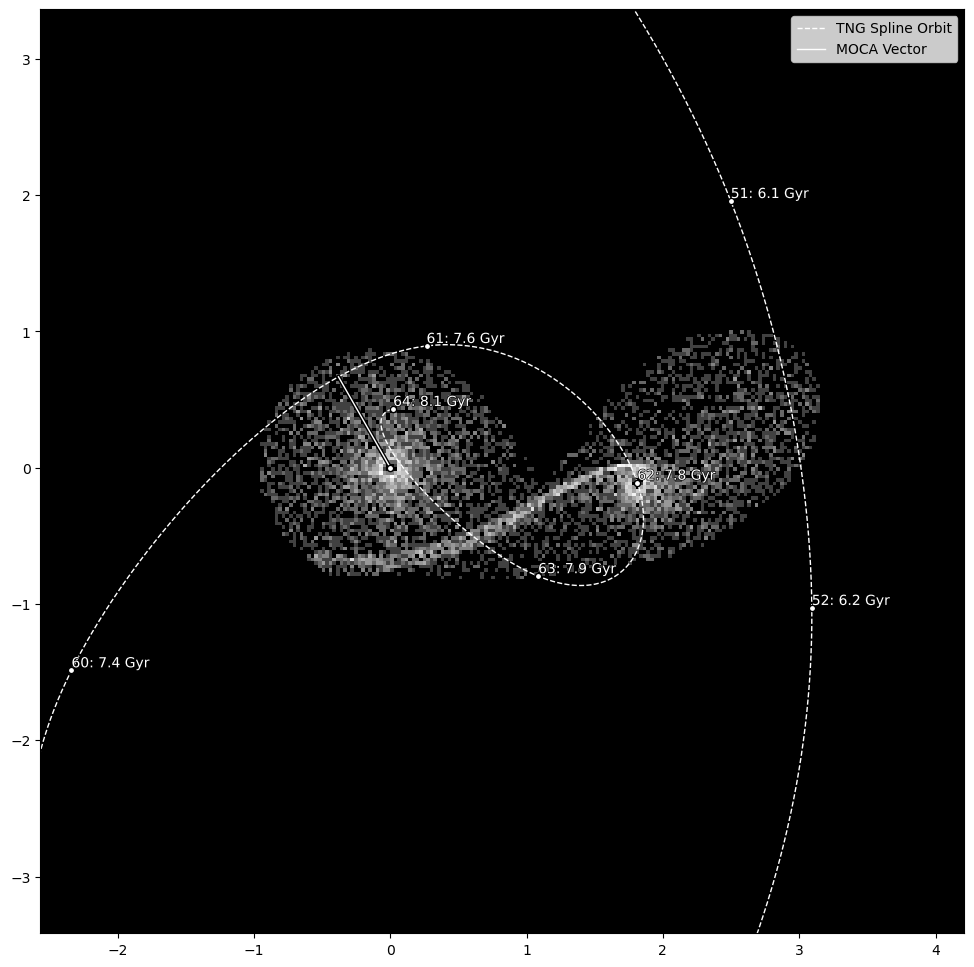

In [22]:
        
# def graph_target(self, ax = None,  overwrite_hist=None, hist_std_dev = 3, log_scale = True,
#                     add_annotations = None, overwrite_annotations = None,
#                     add_plots = None, overwrite_plots = None, 
#                     hard_range = None, show_labels = True,
#                     add_spam_orbits = None,
#                     **kwargs):
    
#     """
#     Graph Target Orbit, Particles, and other information
#     """

#     # Create axis or use given axis
#     if ax is None:
#         figsize = kwargs.get('figsize', (12,12))
#         fig, ax = plt.subplots(1, 1, figsize=figsize)
    
#     # If histogram data to use
#     if overwrite_hist:
#         hist_data = overwrite_hist
#     else:
#         hist_data = self.base_hist_data
    
#     # Set style
#     if isinstance(hist_data, tuple):
#         hist_data, hist_style = hist_data
#     else:
#         hist_style = {'cmap':'gray', 'bins':128, } # Default style
    
#     # Get annotations to use
#     if add_annotations:
#         annotations = self.base_annotations.copy()
#         annotations.extend( add_annotations )
#     elif overwrite_annotations:
#         annotations = overwrite_annotations
#     else:
#         annotations = self.base_annotations
    
#     # Get plots to use
#     if add_plots:
#         plot_list = self.plot_base.copy()
#         plot_list.extend( add_plots )
#     elif overwrite_plots:
#         plot_list = overwrite_plots
#     else:
#         plot_list = self.plot_base
    
#     # Set limits
#     if hard_range:
#         xlim = hard_range[0]
#         ylim = hard_range[1]
#     else:
#         # Use base hist limits
#         limits = self.base_hist_data[1].get('range', None)
#         if limits:
#             xlim = limits[0]
#             ylim = limits[1]
    
#     # if given spam orbits to add to graph
#     if add_spam_orbits is not None:
#         # Ensure it's a list
#         if not isinstance(add_spam_orbits, list):
#             add_spam_orbits = [add_spam_orbits]

#         for i,spam_orbit in enumerate(add_spam_orbits):
#             if isinstance(spam_orbit, tuple):
#                 spam_orbit, spam_name = spam_orbit
#             else:
#                 spam_name = 'SPAM Orbit %d' % i
#             orbit_info = self.gen_spam_orbit_graph_info( spam_orbit, spam_name )
#             plot_list.extend( orbit_info['plot'] )
#             annotations.extend( orbit_info['annotations'] )
    
#     # Create histogram for reference
#     h, xedges, yedges, image = ax.hist2d(hist_data[:, 0], hist_data[:, 1], range=[xlim,ylim], **hist_style)
#     ax.clear()

#     # Apply log scaling to brightness if requested
#     if log_scale: h = np.log1p(h)

#     # Now create image from histogram
#     img = ax.imshow(h.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
#                     origin='lower', cmap=hist_style['cmap'])
#     ax.set_aspect('equal')


#     # Add plots
#     for i,plot_data in enumerate(plot_list):
        
#         # If it has additional info
#         if isinstance(plot_data, tuple):
#             plot_style = plot_data[1]
#             plot_data = plot_data[0]
#         else:
#             plot_style = {'label':'%d' % i, 'linewidth':1}
        
#         # If plot data is a list
#         if isinstance(plot_data, list):
#             plot_data = np.array( plot_data )
        
#         ax.plot( plot_data[:,0], plot_data[:,1], **plot_style )
    
    
#     # Add annotations 
#     for a_loc, a_text in annotations:
        
#         # Check if location is inside graph limits
#         if xlim[0] < a_loc[0] < xlim[1] and ylim[0] < a_loc[1] < ylim[1]:
        
#             ax.scatter( a_loc[0], a_loc[1], s=20, color='w', edgecolor='k', linewidths=1.0, zorder=7 ) # white on black dot
#             txt_obj = ax.text( a_loc[0], a_loc[1], a_text, color='w', fontsize=10, zorder=8, ha='left', va='bottom' )
#             txt_obj.set_path_effects([path_effects.Stroke(linewidth=1, foreground='black'), path_effects.Normal()])
        

#     if show_labels:
#         ax.legend()
    
#     # Reset limits to show
#     ax.set_xlim(xlim)
#     ax.set_ylim(ylim)
#     # end function

# setattr( TNG_Target_Dev_Class, 'graph_target_2', graph_target )

if buildEnv:
    LOGGER.setLevel(logging.INFO)
    test_target = TNG_Target_Dev_Class( p1 )

    _, test_pts = sim.basic_run( test_target.spam_ar, npts1=4000, npts2=4000 )

    test_target.graph_target( overwrite_hist=(test_pts, {'cmap':'gray', 'bins':256, }), )


---
---

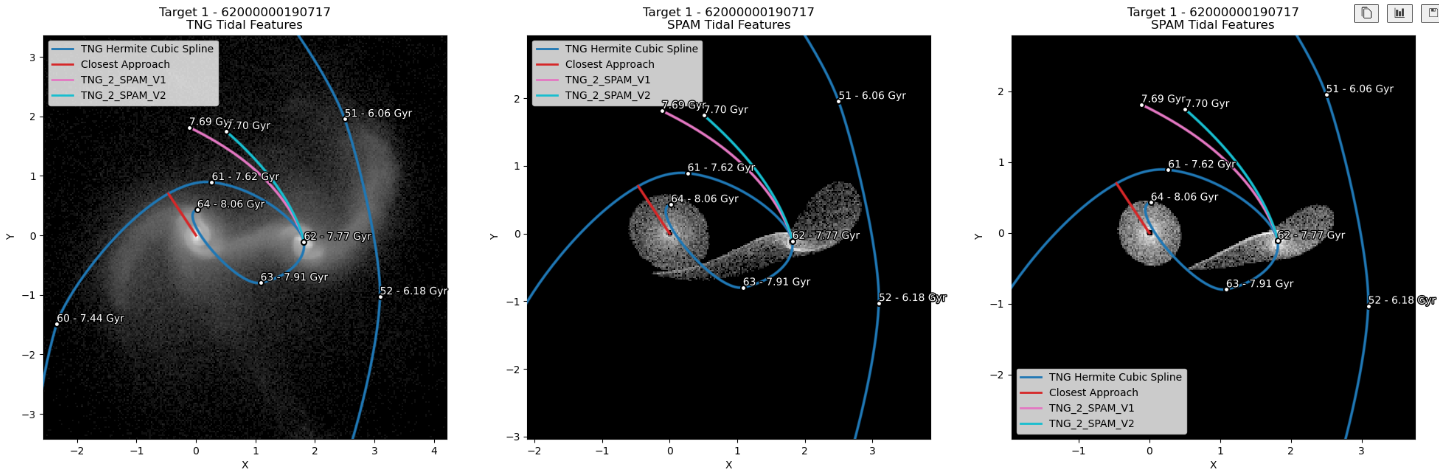

## Comparing v1 and v2
Looking at the orbits and tidal features, we can see that the version 1 and 2 functions of converting TNG target parameters into SPAM parameters do have a slight difference.  (See functions above for more details.)  Because I believe version 2 is more accurate, I will be using that for the actual TNG to SPAM conversion. 

## Comparing TNG to SPAM
Looking at the tidal features of both, we can see that the secondary galaxy is starting to form features.  But not the first.  This could be because the radius isn't long enough however.   Let's try increasing the radius and see if that helps.

---
---

Time:2025-01-30 11:18:09,488 - [new_simulator.spam_orbit] - INFO - Running SPAM Simulation - Orbit Run
Time:2025-01-30 11:18:09,489 - [new_simulator.set_spam_parameters] - INFO - Setting SPAM Parameters: 
Time:2025-01-30 11:18:14,394 - [new_simulator.basic_run] - INFO - Running SPAM Simulation - Basic Run


Size List: [ 1.   3.5  6.   8.5 11. ]
0 - 1.0
(721, 7)


Time:2025-01-30 11:18:14,398 - [new_simulator.set_spam_parameters] - INFO - Setting SPAM Parameters: 
Time:2025-01-30 11:18:24,540 - [new_simulator.spam_orbit] - INFO - Running SPAM Simulation - Orbit Run
Time:2025-01-30 11:18:24,543 - [new_simulator.set_spam_parameters] - INFO - Setting SPAM Parameters: 


Size: 1.00 - (20001, 6)
1 - 3.5


Time:2025-01-30 11:18:28,834 - [new_simulator.basic_run] - INFO - Running SPAM Simulation - Basic Run
Time:2025-01-30 11:18:28,835 - [new_simulator.set_spam_parameters] - INFO - Setting SPAM Parameters: 
Time:2025-01-30 11:18:38,458 - [new_simulator.spam_orbit] - INFO - Running SPAM Simulation - Orbit Run


...

(721, 7)
Size: 6.00 - (20001, 6)
3 - 8.5


Time:2025-01-30 11:18:55,004 - [new_simulator.set_spam_parameters] - INFO - Setting SPAM Parameters: 
Time:2025-01-30 11:18:58,351 - [new_simulator.basic_run] - INFO - Running SPAM Simulation - Basic Run
Time:2025-01-30 11:18:58,353 - [new_simulator.set_spam_parameters] - INFO - Setting SPAM Parameters: 


(721, 7)
Size: 8.50 - (20001, 6)
4 - 11.0


Time:2025-01-30 11:19:07,442 - [new_simulator.spam_orbit] - INFO - Running SPAM Simulation - Orbit Run
Time:2025-01-30 11:19:07,447 - [new_simulator.set_spam_parameters] - INFO - Setting SPAM Parameters: 
Time:2025-01-30 11:19:13,253 - [new_simulator.basic_run] - INFO - Running SPAM Simulation - Basic Run
Time:2025-01-30 11:19:13,255 - [new_simulator.set_spam_parameters] - INFO - Setting SPAM Parameters: 


(721, 7)
Size: 11.00 - (20001, 6)
Plotting


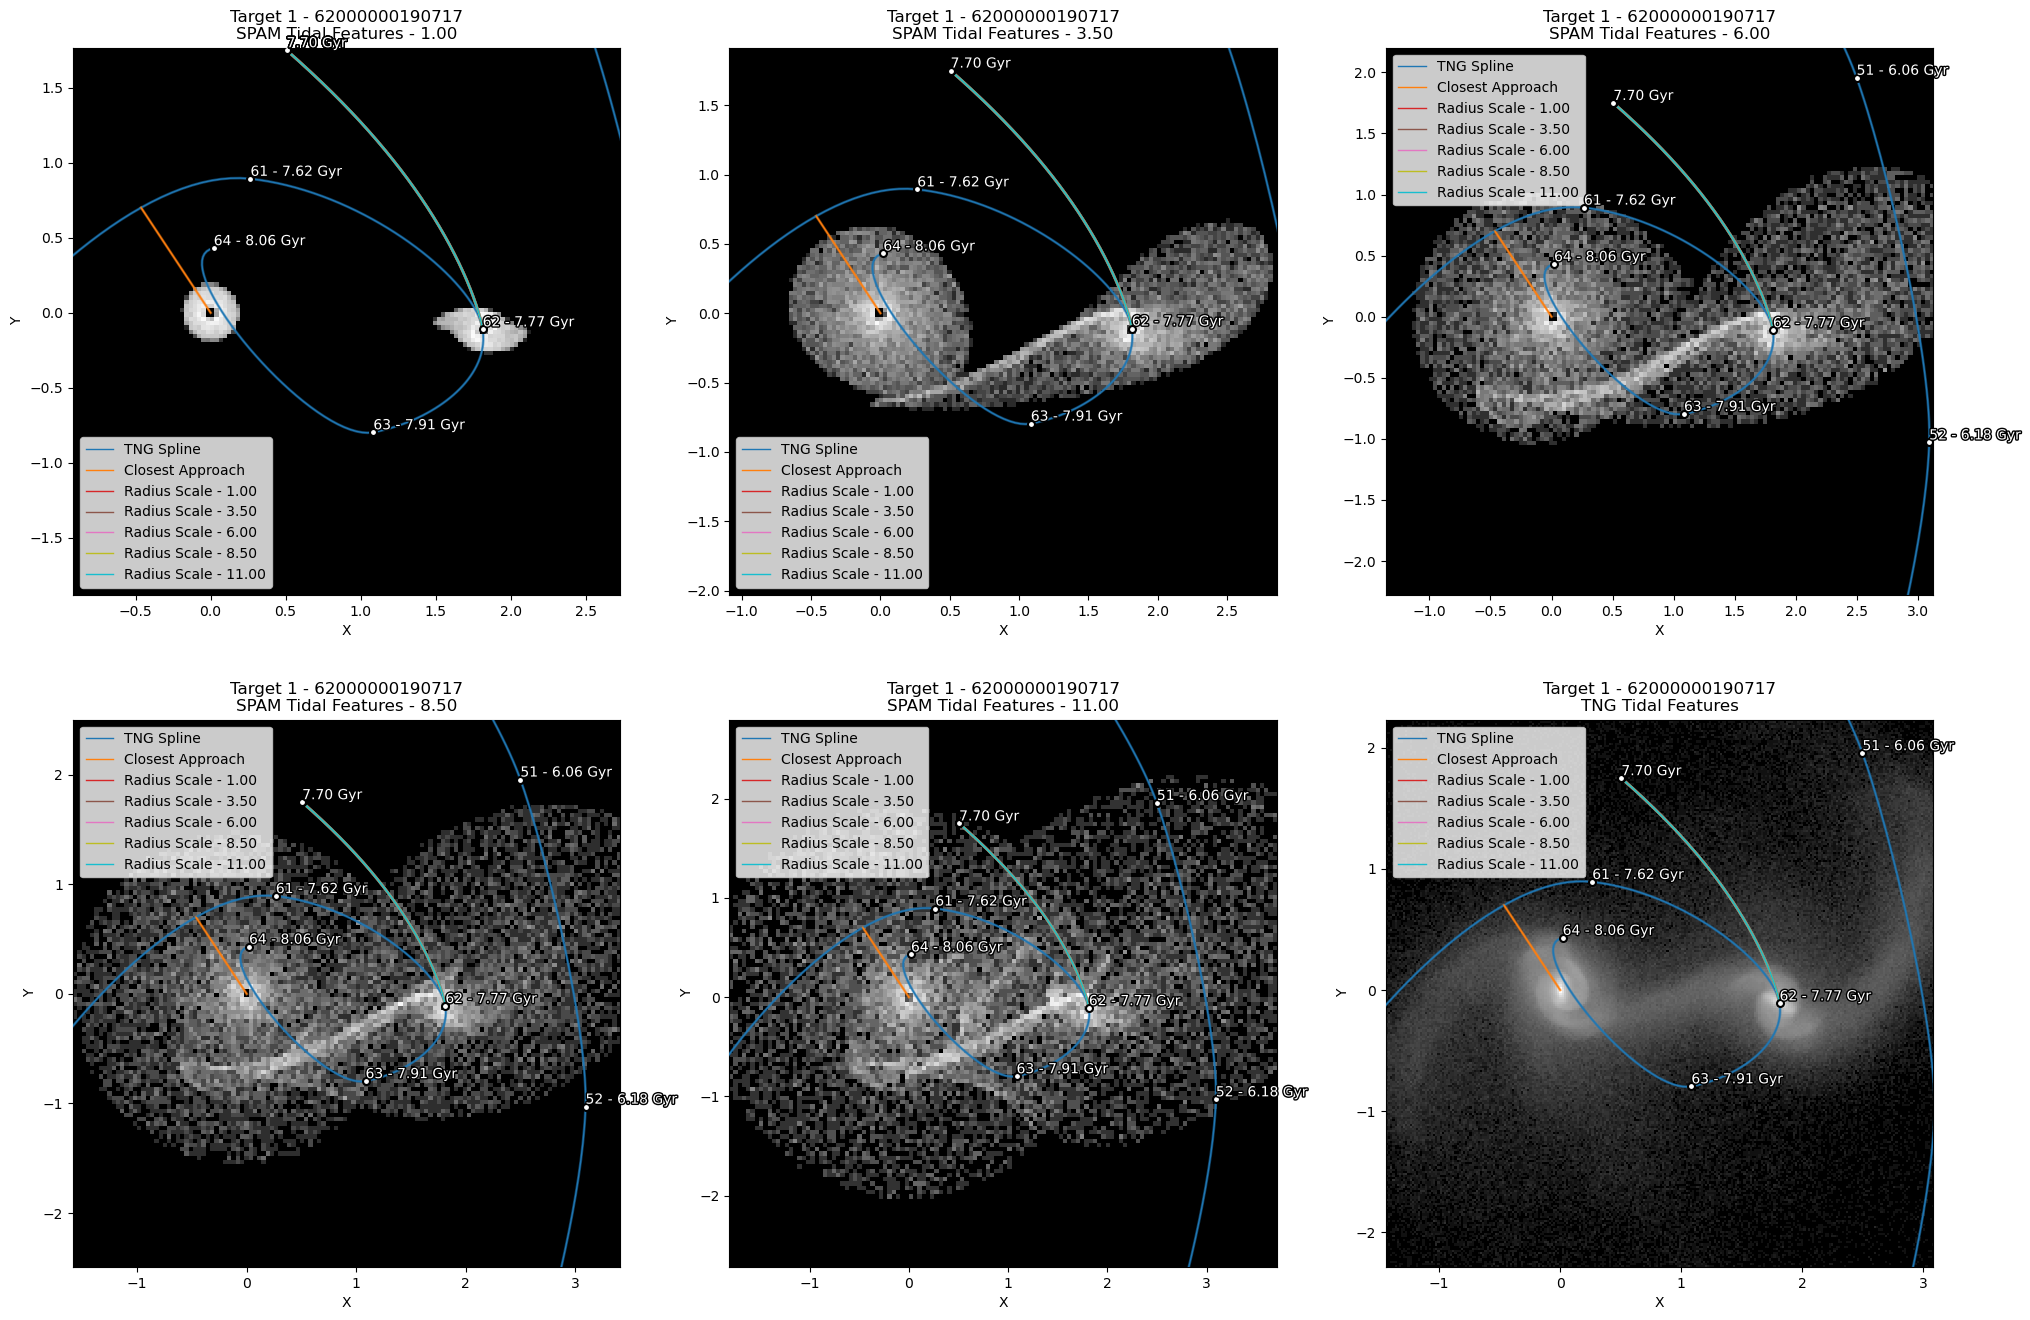

In [23]:
if buildEnv:

    logger.setLevel(logging.INFO)

    # Let's iterate over a few difference sizes of the SPAM orbits
    r_scale_list = np.linspace( 1.0, 11.0, 5 )
    print( f"Size List: {r_scale_list}" )
    # print("Default Size: 2.5")

    overwrite = True
    n_pts = 10000
    if tng_target_1.get('scaled_spam_pts') is None or overwrite:
        tng_target_1['scaled_spam_pts'] = {}
        tng_target_1['scaled_spam_orbit'] = {}
        tng_target_1['reset_plot_info']()
        tmp_annotations = tng_target_1['annotations'].copy()
        tmp_plot_list = tng_target_1['plot_list'].copy()
        tmp_plot_labels = tng_target_1['plot_labels'].copy()


    for i, r in enumerate(r_scale_list):        
        if tng_target_1['scaled_spam_pts'].get(r) is None or overwrite:

            print( f"{i} - {r}" )
            _, spam_ar = tng_target_1['generate_spam_array']( r )
            # print( spam_ar)

            # Get orbit
            tng_target_1['scaled_spam_orbit'][i] = sim.spam_orbit( spam_ar, current_time=tng_target_1['current_time'], spam_setup_params={} )

            print( tng_target_1['scaled_spam_orbit'][i].shape )

            # Get points
            _, tng_target_1['scaled_spam_pts'][i] = sim.basic_run( spam_ar, npts1=n_pts, npts2=n_pts, spam_setup_params={} )

            # Add orbit to plot
            _ = add_spam_orbit_info( tng_target_1['scaled_spam_orbit'][i], tng_target_1, f'Radius Scale - {r:.2f}', True, False )
    
        print( f"Size: {r:.2f} - {tng_target_1['scaled_spam_pts'][i].shape}" )
    
    # Create a 2x3 subplot
    fig, axs = plt.subplots(2, 3, figsize=(24, 16))

    print("Plotting")
    # Iterate left to right for different sizes
    for i, r in enumerate(r_scale_list):
        tf.xy_histogram( \
            tng_target_1['scaled_spam_pts'][i], \
            tng_target_1['plot_list'], tng_target_1['plot_labels'], \
            show_labels = True, std_dev = 2,
            bins = 128,
            annotations= tng_target_1['annotations'],
            title = f'Target 1 - {tng_target_1["current_info"]["p_SubhaloIDRaw"]}\nSPAM Tidal Features - {r:.2f}',
            ext_ax = axs[i//3,i%3]
        )

    # Lower right for TNG
    tf.xy_histogram( \
        tng_target_1['pts'], \
        tng_target_1['plot_list'], tng_target_1['plot_labels'], \
        show_labels = True, std_dev = 2,
        annotations= tng_target_1['annotations'],
        title = f'Target 1 - {tng_target_1["current_info"]["p_SubhaloIDRaw"]}\nTNG Tidal Features',
        ext_ax = axs[-1,-1]
    )

---
---


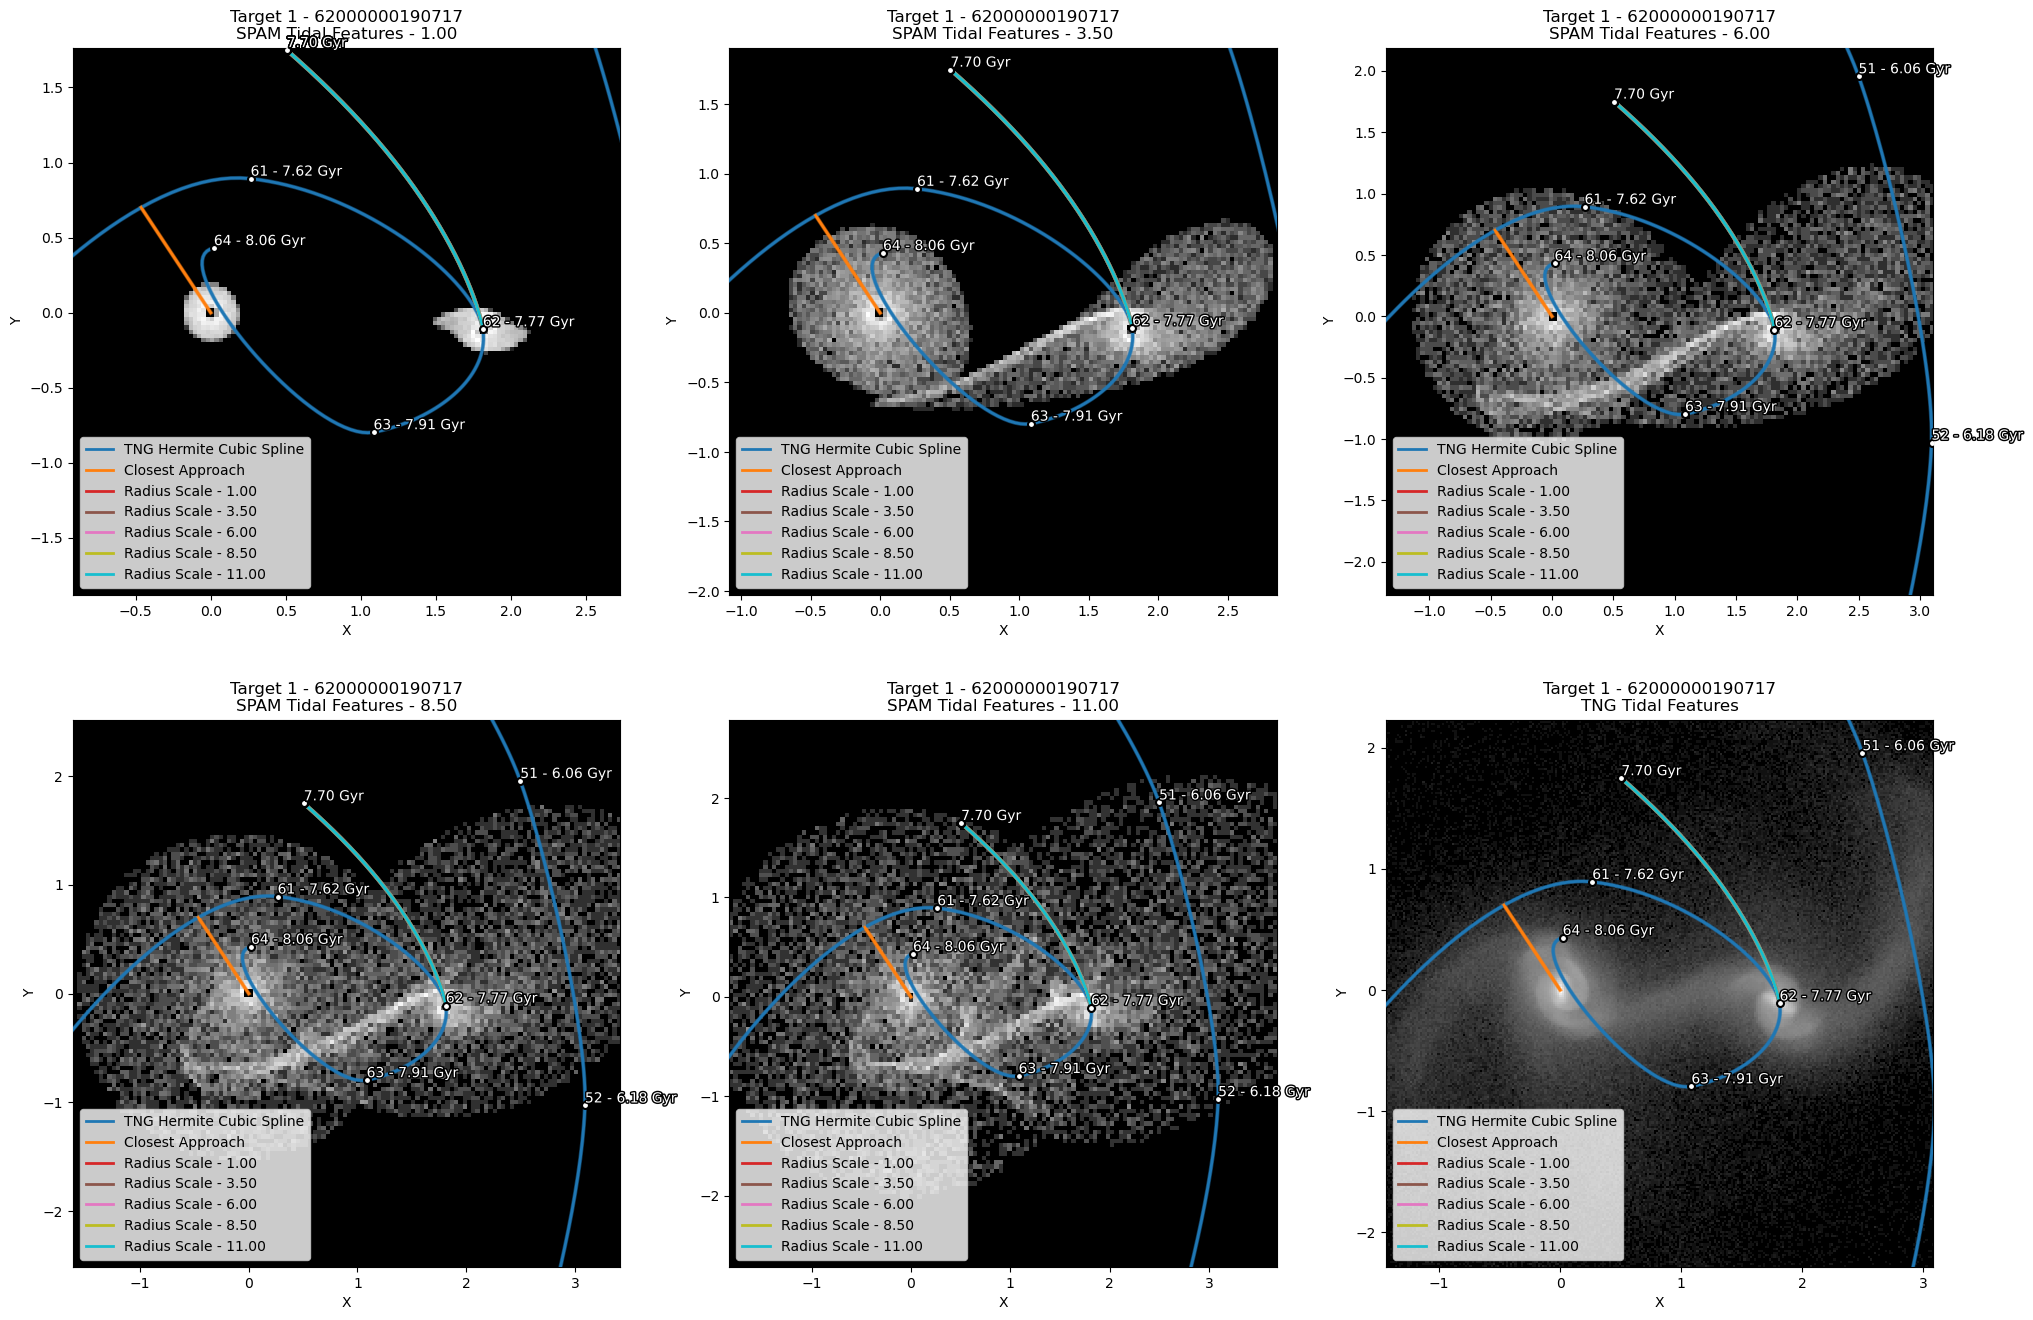
<center>
**Figure: Adjusting SPAM Radius** Scaling the TNG half mass radius up to see affects on tidal features.  Note, the orbits appear to perfectly overlap.  
</center>

# Comparing TNG to SPAM Analysis

So increasing the radius helped show off the tidal features, but it's fairly clear the tidal features DO NOT match up.  This is concerning, because SPAM is supposed to be able to recreate realistic tidal features of merging galaxies. 

## Point 1: Orbits are Off
 Increasing the radius did show more tidal features, however they the resulting SPAM tidal features do not match the TNG tidal features.  I suspect the tidal features are off because the orbits themselves are off.  Based on literature of merging galaxies, the orbit and galaxy dynamics at the moment of closest approach have a high impact on the tidal features.  Thus, adjusting the orbit until it overlaps the tng orbit could create most closely matching tidal features.   **HOWEVER**, we do **NOT** want to change the TNG to SPAM parameters because those values are our control collision parameters (with exception to the TNG half mass radius).  This work is meant to prove SPAM can create tidal features similar to those of more computationally expensive merging simulations.  Thus we need to adjust other parameters.

It also happens that the SPAM simulation has some hyper parameters that are hardcoded.  For instance, there exists a 'lnl' parameter for affecting how strong the dynamical friction is. This was hardcoded during Galaxy Zoo: Mergers, so I've gone ahead and made this an adjustable variable.  Another set of variables I can change is the "unit disk galaxy" SPAM uses.  Based on observations of the Milky Way, SPAM hardcodes the size and mass ratios between the galactic bulge, disk and dark matter halo.  However, more recent literature indicates the dark matter halo could be much larger than previously thought.  Thus, I went ahead and made these variables adjustable as well. 

 **Note about Radius**: The TNG radius is a half mass radius, and the SPAM radius is for the disk of stars.  While they are likely a scale value of one another, I do not know that scale yet and may need to manually adjust this value when I have tidal features to compare.  Alternatively, I could download the particles for these galaxies before they have tidal features, and adjust the radius until the two disks overlap well.  

 ### FUTURE TASK:  Find TNG to SPAM Radius scale
  1) Download TNG particles at previous snapshot. 
  2) Modify radius scale up and down
  3) Find radius scale where disks appear to overlap well
  4) Could use 2D correlation to quantify how well they match.  

## Point 2:  The radius does NOT affect the orbit, only particle distribution.  
Up until this point, I had assumed the radius of the two galaxies would scale up or down the "unit galaxy" SPAM uses to calculate particle acceleration.  However, while changing the radius for the figure above, we can see the orbits all seem to perfectly overlap one another.  I looked deeper into the code of SPAM and verified that while the masses of the two galaxies will affect the strength of acceleration, the radius does **NOT**.    This is concerning, because while experimenting with the radius of the dark matter halo of the SPAM unit galaxy (see figures below), the orbit is definitely affected.  Which makes sense, at this scale the two galaxies are likely traveling through the other's dark matter halo, which would affect accelerations.  This means the size of the unit galaxy SPAM uses to calculate accelerations is set.  While I can change the size and mass ratios of this unit galaxy, I cannot scale their size up and down for each galaxy.  Thus if I have two merging galaxies of very different sizes, SPAM may not recreate their tidal features as well.  At some point in the future I may modify the SPAM code to either scale the strength of acceleration based on a radius value, or do a more intense modification and have it generate two unit galaxies. 

### FUTURE TASK: Have galaxy radii affect acceleration:
1) Scale acceleration based on particle location within dark matter halo of other galaxy.
2) Generate two potential matrices, one for each galaxy.  

---
---

In [24]:
if buildEnv and False:

    logger.setLevel(logging.INFO)
    
    # Empty items default to SPAM Default
    spam_param = {}
    spam_param['Default'] = {}
    spam_param['Off Time'] = { 'm_halo': 10, 'lnl': 0.05 }
    spam_param['Hand Found'] = { 'm_halo': 5.8, 'lnl': 0.007, 'r_scale': 20 }

    # Let's adjust the SPAM parameters to see if we can get a better match
    overwrite = True
    
    if overwrite or not orbits:
        tng_target_1 = tng_target_1['reset_plot_info']()    
        orbits = {}    

    spam_ar = tng_target_1['generate_spam_array'](5.0)[0]
    for k, v in spam_param.items():
        if orbits.get(k) is None or overwrite:
            print( f"Running: {k}" )
            orbits[k] = {}
            orbits[k]['orbit'] = sim.spam_orbit( spam_ar, current_time=tng_target_1['current_time'], spam_setup_params=v )
            _ = add_spam_orbit_info( orbits[k]['orbit'], tng_target_1, f'SPAM - {k}', True, False )
            orbits[k]['pts'] = sim.basic_run( spam_ar, npts1=10000, npts2=20000, spam_setup_params=v, heat1=0.2, heat2=0.2 )[1]

    # Let's create side by side plots
    fig, axs = plt.subplots(2, 2, figsize=(24, 24))
    
    # Let's plot the new orbit
    xy_histogram( \
        tng_target_1['pts'], \
        tng_target_1['plot_list'], tng_target_1['plot_labels'], \
        show_labels = True, std_dev = 3,
        annotations= tng_target_1['annotations'],
        title = f'Target 1 - {tng_target_1["current_info"]["p_SubhaloIDRaw"]}\nTNG Particles',
        # figsize=(12,12),
        ext_ax = axs[0,0],
    )

    # Loop through other three plots
    for i, (k, v) in enumerate(orbits.items()):
        xy_histogram( \
            v['pts'], \
            tng_target_1['plot_list'], tng_target_1['plot_labels'], \
            show_labels = True, std_dev = 2,
            annotations= tng_target_1['annotations'],
            title = f'Target 1 - {tng_target_1["current_info"]["p_SubhaloIDRaw"]}\nSPAM Particles - {k}',
            bins=200,
            ext_ax = axs[(i+1)//2,(i+1)%2],
        )
        

---
---
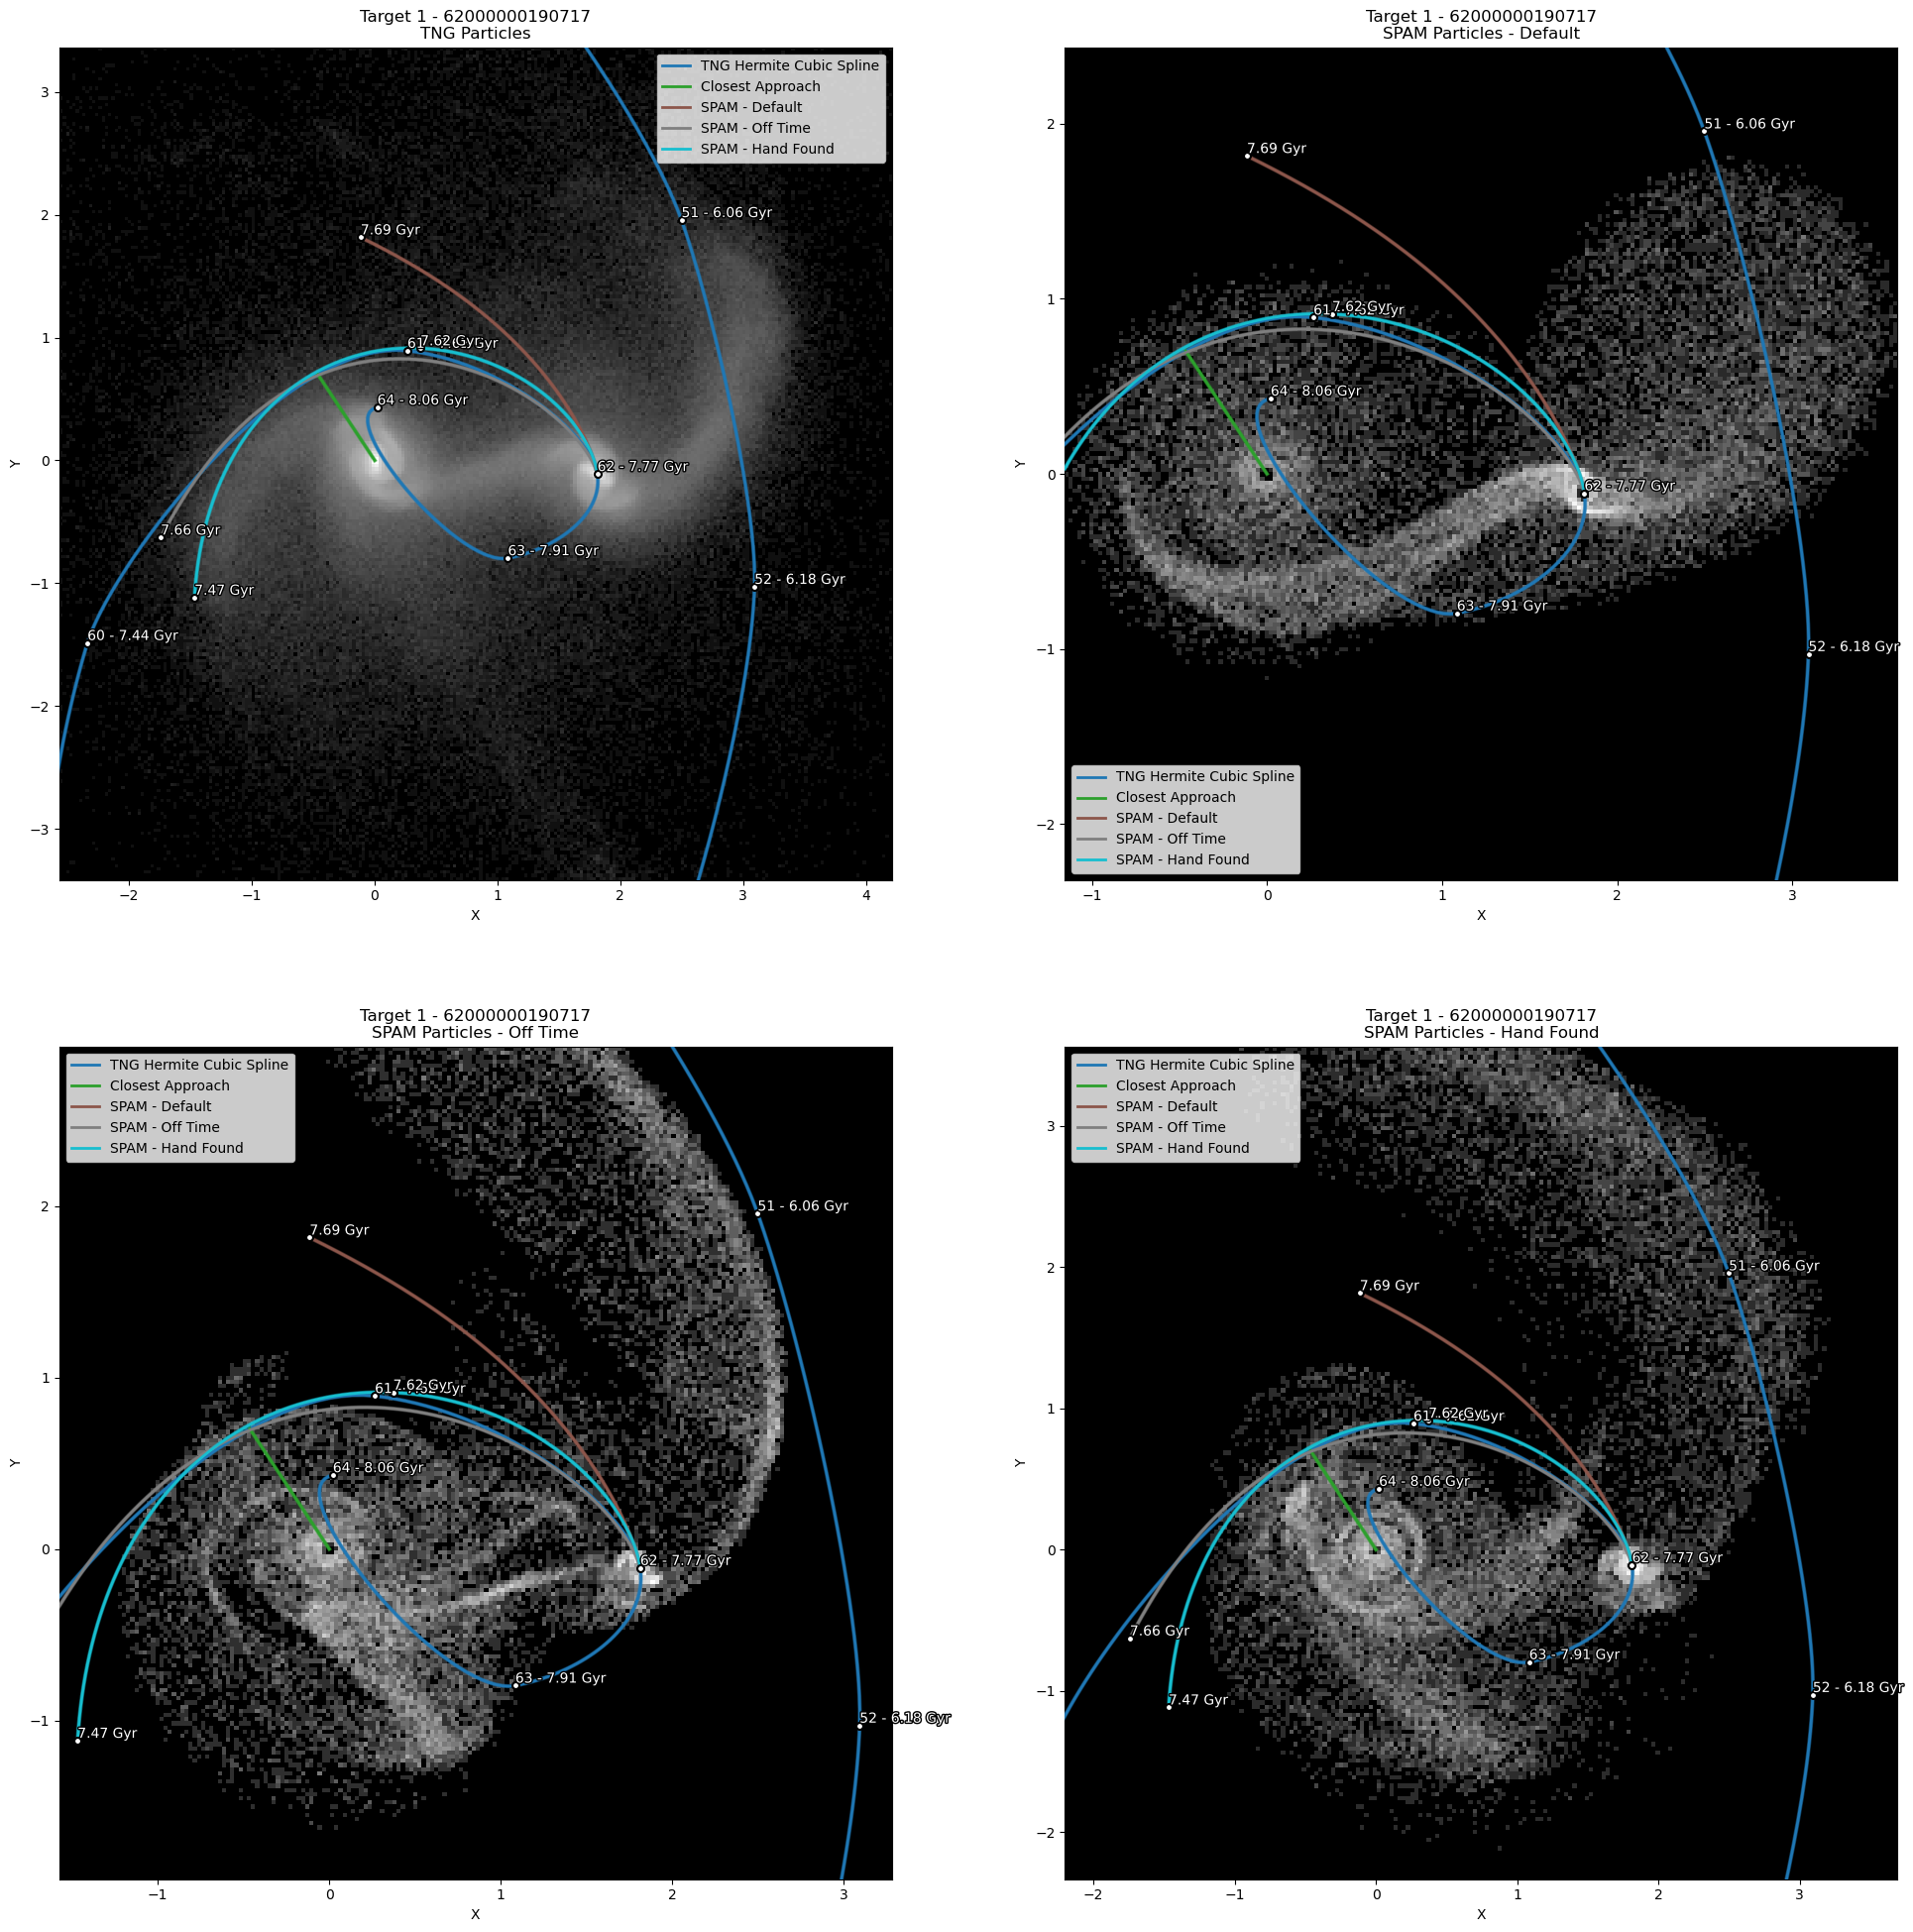
<center>
Figure: SPAM Tidal Features of Overlapping Orbits.
</center>

# Wonderful Success!

As suspected, by adjusting the SPAM hyperparameters, we can get the orbits to overlaps.  Once they overlap, several major tidal features begin to form that closely match the TNG tidal features.  This is a huge success and shows that SPAM can simulate the tidal features of colliding galaxies.  Why they are note perfect, these orbits were found by hand, and using an optimization function could likely find better solutions/orbits.  Do note, I found two orbits that overlap well at the moment of closest approach.  However, if you look at the starting times for their orbits, you'll note they have very different times.  One of them is moving much faster than the other, yet both produced tidal features that resemble the TNG tidal features.

---
---
# OKAY MATTHEW, END SCRIPT

So I *had* an entire 2nd half to this notebook that's all about creating orbit fitness functions and doing a gridsearch of the SPAM parameters, then the beginnings of an optimization program (And fixings bugs after *hours* of  compuations).  But the notebook got FAR too long (1900 ish lines here).  And I started getting overwhelmed trying to scroll up and down, making edits, and rerunning everything; so I'm going to end this here.  I am making a new script for tuning the SPAM Simulation Parameters within the Simulation Directory.